# Deep AnaLysis of BlAcK Friday with ML

## 📦 Import Libraries

In [1]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import glob
from datetime import datetime

# ── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
# ── Settings ─────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Plot Style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
sns.set_palette('tab10')
# ── Color Palettes ────────────────────────────────────────────────────────────
COLORS = ['#2196F3','#FF9800','#4CAF50','#E91E63','#9C27B0',
          '#00BCD4','#FF5722','#607D8B','#8BC34A','#FFC107']
CMAP   = 'coolwarm'

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


## 📂  Load Data

In [2]:
# ── Auto-detect dataset path ──────────────────────────────────────────────────

df = pd.read_csv('/content/retail_black_friday_sales_100k.csv')
print(f'\n✅ Loaded: sucessfully')


✅ Loaded: sucessfully


In [3]:
# ── Basic Inspection ─────────────────────────────────────────────────────────
print('=' * 60)
print(f'📐 Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns')
print('=' * 60)

print('\n📋 Column Names:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:>2}. {col}')

📐 Shape   : 100,000 rows × 18 columns

📋 Column Names:
   1. transaction_id
   2. customer_id
   3. age_group
   4. gender
   5. city
   6. customer_segment
   7. product_id
   8. product_category
   9. original_price
  10. discount_pct
  11. final_price
  12. quantity
  13. purchase_amount
  14. payment_method
  15. purchase_date
  16. purchase_hour
  17. is_weekend
  18. is_black_friday


In [4]:
# ── Head ─────────────────────────────────────────────────────────────────────
print('\n🔍 First 5 rows:')
df.head()


🔍 First 5 rows:


,transaction_id,customer_id,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,is_weekend,is_black_friday
0,T0000001,C007297,26-35,Male,San Francisco,Loyal,P2713,Footwear,153.73,35,99.92,1,99.92,Credit Card,2025-12-01,0,0,0
1,T0000002,C001640,56+,Other,Dallas,Returning,P7219,Beauty,230.05,40,138.03,1,138.03,PayPal,2025-11-24,5,0,0
2,T0000003,C018025,26-35,Male,Phoenix,New,P5521,Groceries,174.67,25,131.00,1,131.00,Credit Card,2025-11-24,14,0,0
3,T0000004,C016050,18-25,Other,Miami,VIP,P3003,Sports,399.61,40,239.77,1,239.77,Credit Card,2025-11-30,23,1,0
4,T0000005,C014629,46-55,Male,Los Angeles,Loyal,P4633,Footwear,120.87,30,84.61,2,169.22,Debit Card,2025-11-25,2,0,0


In [5]:
# ── Info & Describe ──────────────────────────────────────────────────────────
print('\n📊 DataFrame Info:')
df.info()
print('\n📈 Descriptive Statistics:')
df.describe(include='all')



📊 DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    100000 non-null  object 
 1   customer_id       100000 non-null  object 
 2   age_group         100000 non-null  object 
 3   gender            100000 non-null  object 
 4   city              100000 non-null  object 
 5   customer_segment  100000 non-null  object 
 6   product_id        100000 non-null  object 
 7   product_category  100000 non-null  object 
 8   original_price    100000 non-null  float64
 9   discount_pct      100000 non-null  int64  
 10  final_price       100000 non-null  float64
 11  quantity          100000 non-null  int64  
 12  purchase_amount   100000 non-null  float64
 13  payment_method    100000 non-null  object 
 14  purchase_date     100000 non-null  object 
 15  purchase_hour     100000 non-null  int64  
 16  is

,transaction_id,customer_id,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,is_weekend,is_black_friday
count,100000,100000,100000,100000,100000,100000,100000,100000,100000.00,100000.00,100000.00,100000.00,100000.00,100000,100000,100000.00,100000.00,100000.00
unique,100000,32997,5,3,10,4,9000,10,NaN,NaN,NaN,NaN,NaN,6,8,NaN,NaN,NaN
top,T0099984,C016694,36-45,Female,New York,Returning,P9694,Accessories,NaN,NaN,NaN,NaN,NaN,Debit Card,2025-11-27,NaN,NaN,NaN
freq,1,12,20145,33460,10105,34946,25,10156,NaN,NaN,NaN,NaN,NaN,16772,12722,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,330.28,26.63,242.22,1.45,351.26,NaN,NaN,11.48,0.25,0.13
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,444.32,12.25,332.68,0.82,589.86,NaN,NaN,6.91,0.43,0.33
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.00,5.00,2.07,1.00,2.22,NaN,NaN,0.00,0.00,0.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.12,20.00,62.94,1.00,75.75,NaN,NaN,5.00,0.00,0.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.22,25.00,129.49,1.00,161.15,NaN,NaN,11.00,0.00,0.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,333.71,35.00,247.57,2.00,358.72,NaN,NaN,17.00,0.00,0.00


In [6]:
# ── Key Counts ───────────────────────────────────────────────────────────────
COLS = df.columns.tolist()

def col(name_hint):
    """Case-insensitive partial column match helper."""
    matches = [c for c in COLS if name_hint.lower() in c.lower()]
    return matches[0] if matches else None

CUST_COL   = col('customer_id') or col('customer')
PROD_COL   = col('product_id')  or col('product')
CAT_COL    = col('product_category') or col('category')
AMT_COL    = col('purchase_amount') or col('transaction_value') or col('final_price')
DATE_COL   = col('purchase_date') or col('date')
HOUR_COL   = col('purchase_hour') or col('hour')
WEEKEND_COL= col('is_weekend') or col('weekend')
DISC_COL   = col('discount_pct') or col('discount')
QTY_COL    = col('quantity') or col('qty')
PRICE_COL  = col('original_price') or col('price')
FINAL_COL  = col('final_price') or col('final')
TV_COL     = col('transaction_value')
AGE_COL    = col('age_group') or col('age')
GENDER_COL = col('gender')
CITY_COL   = col('city')
SEG_COL    = col('customer_segment') or col('segment')
PAY_COL    = col('payment_method') or col('payment')

print('🔑 Column Mapping:')
mapping = {
    'Customer ID': CUST_COL, 'Product ID': PROD_COL, 'Category': CAT_COL,
    'Purchase Amount': AMT_COL, 'Date': DATE_COL, 'Hour': HOUR_COL,
    'Weekend': WEEKEND_COL, 'Discount %': DISC_COL, 'Quantity': QTY_COL,
    'Original Price': PRICE_COL, 'Final Price': FINAL_COL, 'Age Group': AGE_COL,
    'Gender': GENDER_COL, 'City': CITY_COL, 'Segment': SEG_COL, 'Payment': PAY_COL
}
for k, v in mapping.items():
    print(f'  {k:<20} → {v}')

print(f'\n👥 Unique Customers : {df[CUST_COL].nunique():,}' if CUST_COL else '')
print(f'📦 Unique Products   : {df[PROD_COL].nunique():,}' if PROD_COL else '')
print(f'🏷️  Product Categories: {df[CAT_COL].nunique():,}' if CAT_COL else '')

🔑 Column Mapping:
  Customer ID          → customer_id
  Product ID           → product_id
  Category             → product_category
  Purchase Amount      → purchase_amount
  Date                 → purchase_date
  Hour                 → purchase_hour
  Weekend              → is_weekend
  Discount %           → discount_pct
  Quantity             → quantity
  Original Price       → original_price
  Final Price          → final_price
  Age Group            → age_group
  Gender               → gender
  City                 → city
  Segment              → customer_segment
  Payment              → payment_method

👥 Unique Customers : 32,997
📦 Unique Products   : 9,000
🏷️  Product Categories: 10


## 🧹  Data Cleaning & Preprocessing

Before any analysis we verify data integrity. The steps below check for:

    * Missing values — quantified and handled

    * Duplicates — identified and removed

    * Data types — corrected for dates and numerics

    * Categorical values — inspected for typos or inconsistencies
    
    * Outliers — flagged using IQR method on monetary columns


In [7]:
# ── Missing Values ────────────────────────────────────────────────────────────
print('🔍 Missing Value Analysis:')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

if missing_df.empty:
    print('  ✅ No missing values found!')
else:
    print(missing_df)

# Visualise if there are missing values
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Missing %'].plot(kind='barh', ax=ax, color='#E91E63')
    ax.set_title('Missing Value Percentage by Column')
    ax.set_xlabel('Missing %')
    plt.tight_layout()
    plt.show()


🔍 Missing Value Analysis:
  ✅ No missing values found!


In [8]:
# ── Duplicate Rows ────────────────────────────────────────────────────────────
dupes = df.duplicated().sum()
print(f'🔁 Duplicate rows: {dupes:,}')
if dupes > 0:
    df = df.drop_duplicates()
    print(f'  → Removed. New shape: {df.shape}')

🔁 Duplicate rows: 0


In [9]:
# ── Data Type Corrections ─────────────────────────────────────────────────────
# Parse date if column exists
if DATE_COL:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
    print(f'📅 Converted "{DATE_COL}" to datetime.')
    df['purchase_month']   = df[DATE_COL].dt.month
    df['purchase_day']     = df[DATE_COL].dt.day
    df['purchase_weekday'] = df[DATE_COL].dt.dayofweek   # 0=Mon, 6=Sun
    df['purchase_week']    = df[DATE_COL].dt.isocalendar().week.astype(int)
    print('   → Extracted: purchase_month, purchase_day, purchase_weekday, purchase_week')

print('\n📋 Current dtypes:')
print(df.dtypes)

📅 Converted "purchase_date" to datetime.
   → Extracted: purchase_month, purchase_day, purchase_weekday, purchase_week

📋 Current dtypes:
transaction_id              object
customer_id                 object
age_group                   object
gender                      object
city                        object
customer_segment            object
product_id                  object
product_category            object
original_price             float64
discount_pct                 int64
final_price                float64
quantity                     int64
purchase_amount            float64
payment_method              object
purchase_date       datetime64[ns]
purchase_hour                int64
is_weekend                   int64
is_black_friday              int64
purchase_month               int32
purchase_day                 int32
purchase_weekday             int32
purchase_week                int64
dtype: object


In [10]:
# ── Categorical Inspection ────────────────────────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('📂 Categorical Columns & Unique Values:')
for c in cat_cols:
    vals = df[c].value_counts().head(10)
    print(f'\n  {c} ({df[c].nunique()} unique):')
    print(vals.to_string())

📂 Categorical Columns & Unique Values:

  transaction_id (100000 unique):
transaction_id
T0099984    1
T0099983    1
T0099982    1
T0099981    1
T0099980    1
T0099979    1
T0099978    1
T0099977    1
T0099976    1
T0099975    1

  customer_id (32997 unique):
customer_id
C016694    12
C019611    11
C005664    11
C011662    10
C028102    10
C021437    10
C033266    10
C018939    10
C008524    10
C029617    10

  age_group (5 unique):
age_group
36-45    20145
46-55    20014
18-25    19974
26-35    19960
56+      19907

  gender (3 unique):
gender
Female    33460
Male      33396
Other     33144

  city (10 unique):
city
New York         10105
Seattle          10097
Atlanta          10075
Miami            10036
Phoenix          10032
Houston          10024
Dallas            9990
San Francisco     9968
Chicago           9954
Los Angeles       9719

  customer_segment (4 unique):
customer_segment
Returning    34946
New          29956
Loyal        25130
VIP           9968

  product_id (9000 

In [11]:
# ── Outlier Detection (IQR Method) ───────────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Focus on monetary/quantity columns
check_cols = [c for c in num_cols if any(
    kw in c.lower() for kw in ['price','amount','value','quantity','discount']
)]

print('📊 Outlier Summary (IQR method):')
outlier_summary = []
for c in check_cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[c] < lower) | (df[c] > upper)).sum()
    outlier_summary.append({'Column': c, 'Lower Bound': lower, 'Upper Bound': upper, 'Outlier Count': n_out})

print(pd.DataFrame(outlier_summary).to_string(index=False))

📊 Outlier Summary (IQR method):
         Column  Lower Bound  Upper Bound  Outlier Count
 original_price      -280.27       702.10          11819
   discount_pct        -2.50        57.50           1997
    final_price      -214.01       524.53          11476
       quantity        -0.50         3.50           3979
purchase_amount      -348.71       783.18          10897


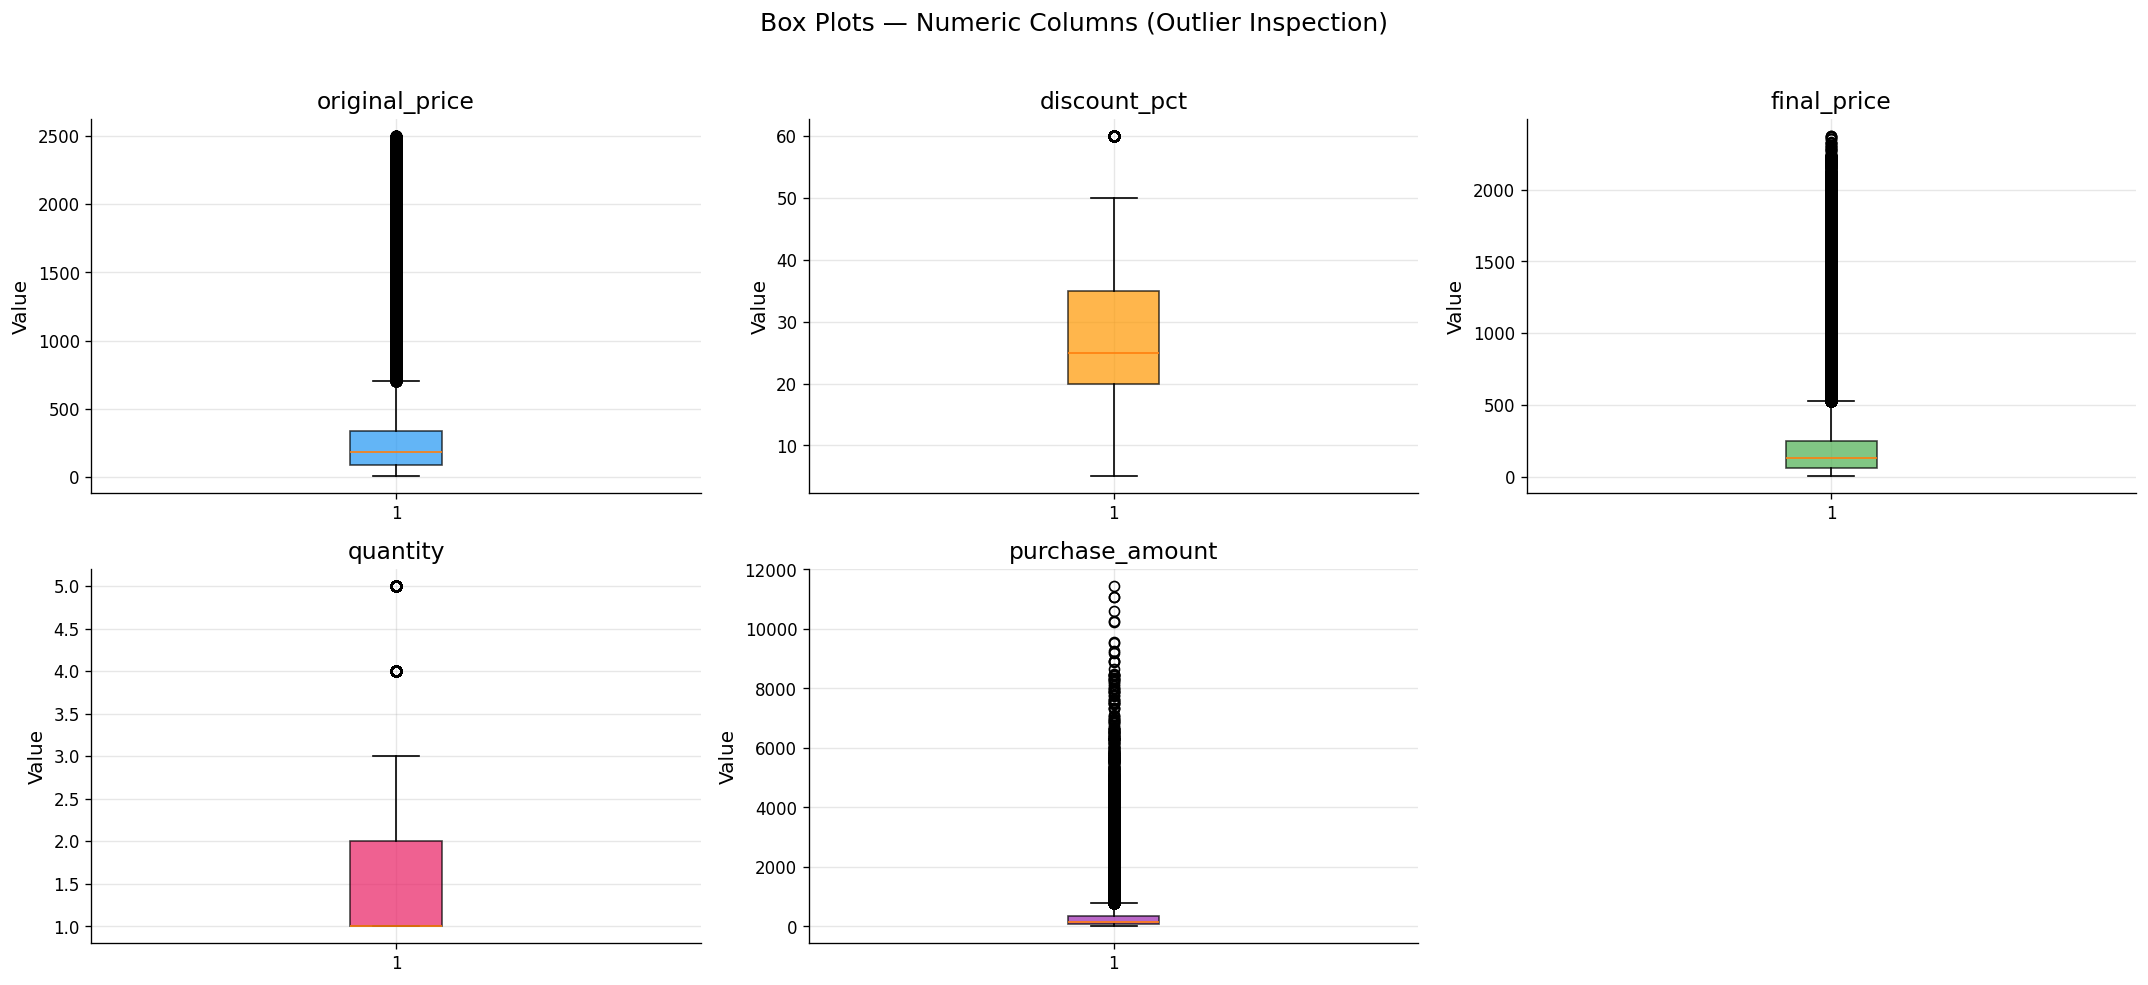

In [12]:
# ── Box Plots for Key Numeric Columns ─────────────────────────────────────────
if check_cols:
    n = len(check_cols)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
    axes = np.array(axes).flatten()

    for i, c in enumerate(check_cols):
        axes[i].boxplot(df[c].dropna(), patch_artist=True,
                        boxprops=dict(facecolor=COLORS[i % len(COLORS)], alpha=0.7))
        axes[i].set_title(c)
        axes[i].set_ylabel('Value')

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Box Plots — Numeric Columns (Outlier Inspection)', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

## 📊  Exploratory Data Analysis (EDA)

### Customer Demographics Analysis¶

Understanding who is shopping is the foundation of retail strategy. We analyze age groups, gender, city, and customer segment to identify the highest-value customer profiles.

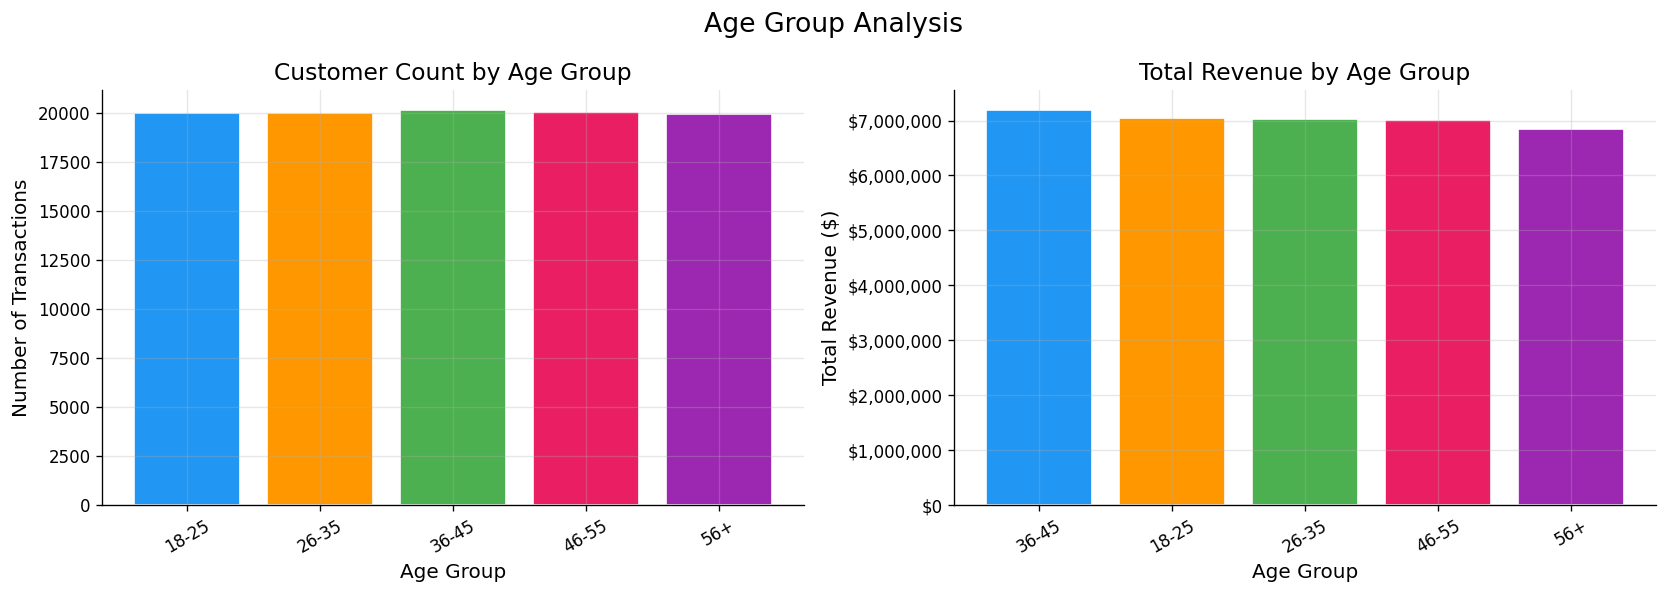

💡 Top Revenue Age Groups:
age_group
36-45   7196872.71
18-25   7051066.02
26-35   7021938.74


In [13]:
# ── Age Group Distribution ────────────────────────────────────────────────────
if AGE_COL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    age_counts = df[AGE_COL].value_counts().sort_index()
    axes[0].bar(age_counts.index, age_counts.values, color=COLORS[:len(age_counts)], edgecolor='white')
    axes[0].set_title('Customer Count by Age Group')
    axes[0].set_xlabel('Age Group')
    axes[0].set_ylabel('Number of Transactions')
    axes[0].tick_params(axis='x', rotation=30)

    if AMT_COL:
        age_revenue = df.groupby(AGE_COL)[AMT_COL].sum().sort_values(ascending=False)
        axes[1].bar(age_revenue.index, age_revenue.values, color=COLORS[:len(age_revenue)], edgecolor='white')
        axes[1].set_title('Total Revenue by Age Group')
        axes[1].set_xlabel('Age Group')
        axes[1].set_ylabel('Total Revenue ($)')
        axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
        axes[1].tick_params(axis='x', rotation=30)

    fig.suptitle('Age Group Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()
    if AMT_COL:
        print('💡 Top Revenue Age Groups:')
        print(age_revenue.head(3).to_string())


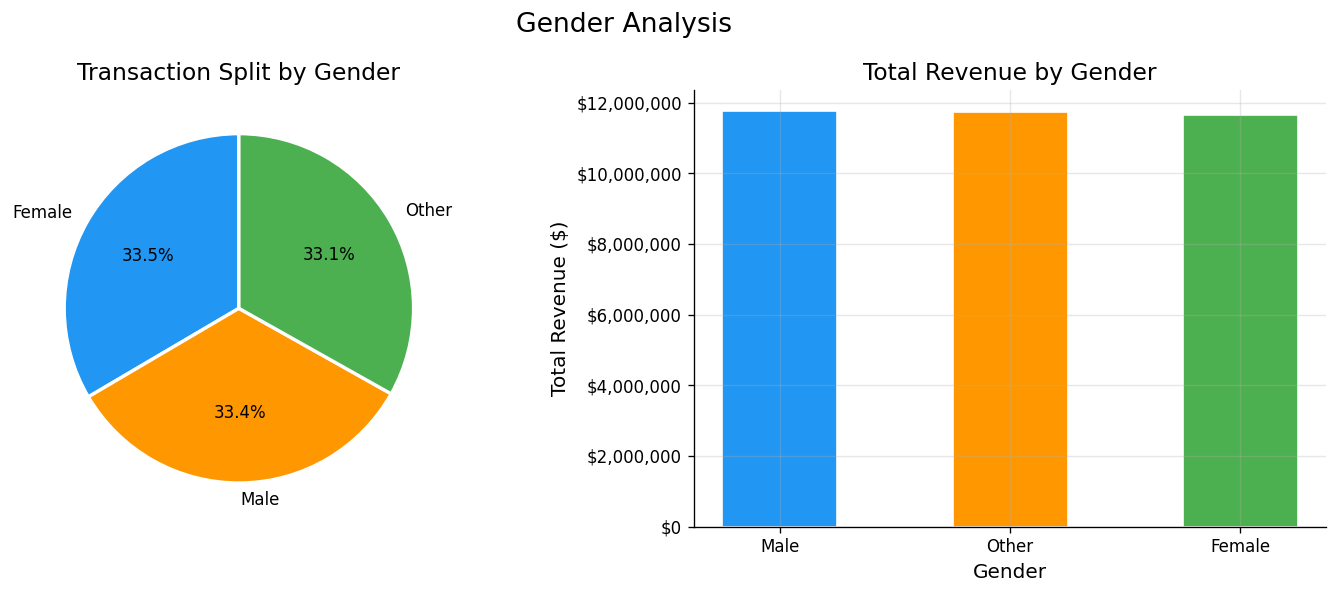

In [14]:
# ── Gender Distribution ───────────────────────────────────────────────────────
if GENDER_COL:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    gender_counts = df[GENDER_COL].value_counts()
    axes[0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
                colors=COLORS[:len(gender_counts)], startangle=90,
                wedgeprops=dict(edgecolor='white', linewidth=2))
    axes[0].set_title('Transaction Split by Gender')

    if AMT_COL:
        gender_rev = df.groupby(GENDER_COL)[AMT_COL].sum().sort_values(ascending=False)
        axes[1].bar(gender_rev.index, gender_rev.values,
                    color=COLORS[:len(gender_rev)], edgecolor='white', width=0.5)
        axes[1].set_title('Total Revenue by Gender')
        axes[1].set_xlabel('Gender')
        axes[1].set_ylabel('Total Revenue ($)')
        axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    fig.suptitle('Gender Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()


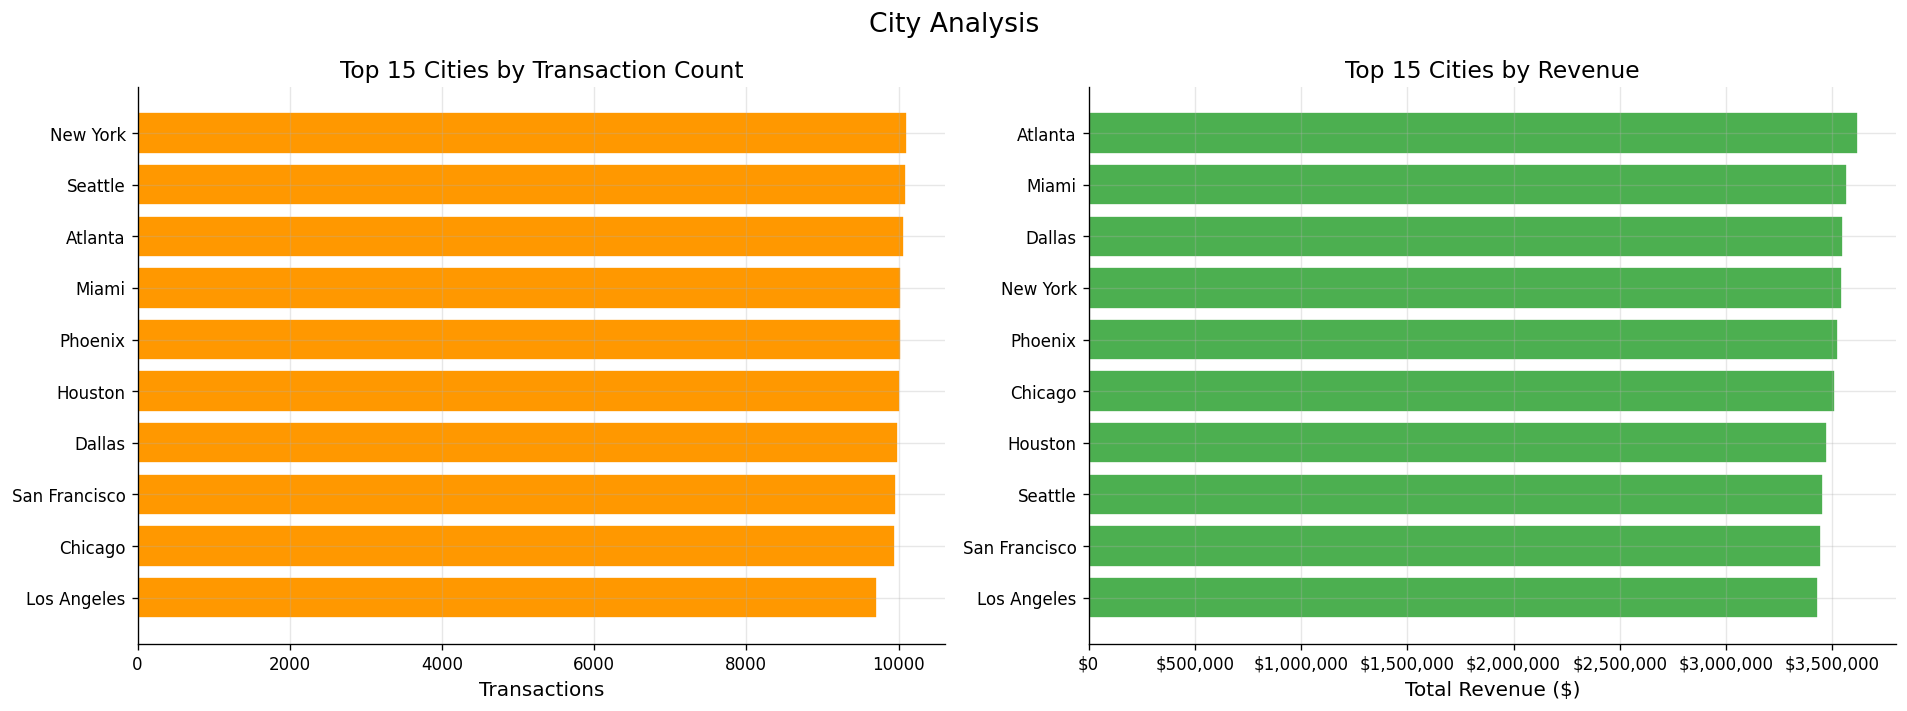

In [15]:
# ── City Distribution ────────────────────────────────────────────────────────
if CITY_COL:
    top_n = 15
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    city_counts = df[CITY_COL].value_counts().head(top_n)
    axes[0].barh(city_counts.index[::-1], city_counts.values[::-1],
                 color=COLORS[1], edgecolor='white')
    axes[0].set_title(f'Top {top_n} Cities by Transaction Count')
    axes[0].set_xlabel('Transactions')

    if AMT_COL:
        city_rev = df.groupby(CITY_COL)[AMT_COL].sum().nlargest(top_n)
        axes[1].barh(city_rev.index[::-1], city_rev.values[::-1],
                     color=COLORS[2], edgecolor='white')
        axes[1].set_title(f'Top {top_n} Cities by Revenue')
        axes[1].set_xlabel('Total Revenue ($)')
        axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    fig.suptitle('City Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()



💡 Revenue by Segment:
                  Total Revenue  Avg Revenue per Transaction
customer_segment                                            
Returning           12125507.74                       346.98
New                 10574443.42                       353.00
Loyal                8888416.70                       353.70
VIP                  3537262.81                       354.86


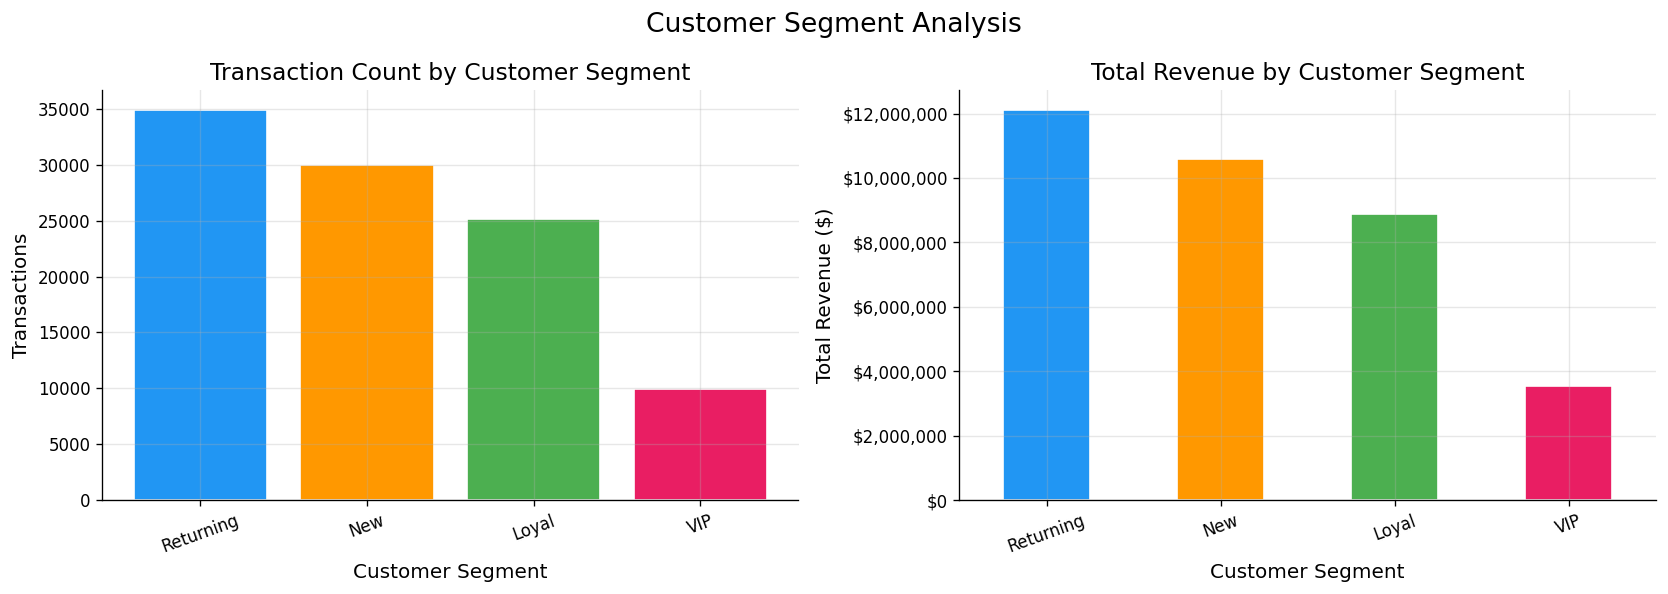

In [16]:
# ── Customer Segment Distribution ────────────────────────────────────────────
if SEG_COL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    seg_counts = df[SEG_COL].value_counts()
    axes[0].bar(seg_counts.index, seg_counts.values,
                color=COLORS[:len(seg_counts)], edgecolor='white')
    axes[0].set_title('Transaction Count by Customer Segment')
    axes[0].set_xlabel('Customer Segment')
    axes[0].set_ylabel('Transactions')
    axes[0].tick_params(axis='x', rotation=20)

    if AMT_COL:
        seg_rev = df.groupby(SEG_COL)[AMT_COL].agg(['sum', 'mean']).sort_values('sum', ascending=False)
        seg_rev['sum'].plot(kind='bar', ax=axes[1],
                            color=COLORS[:len(seg_rev)], edgecolor='white')
        axes[1].set_title('Total Revenue by Customer Segment')
        axes[1].set_xlabel('Customer Segment')
        axes[1].set_ylabel('Total Revenue ($)')
        axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
        axes[1].tick_params(axis='x', rotation=20)

        print('\n💡 Revenue by Segment:')
        seg_rev.columns = ['Total Revenue', 'Avg Revenue per Transaction']
        print(seg_rev.to_string())

    fig.suptitle('Customer Segment Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()


### Product Analysis¶

Understanding product category performance helps retailers decide which categories to promote, stock, and price aggressively during sales events.

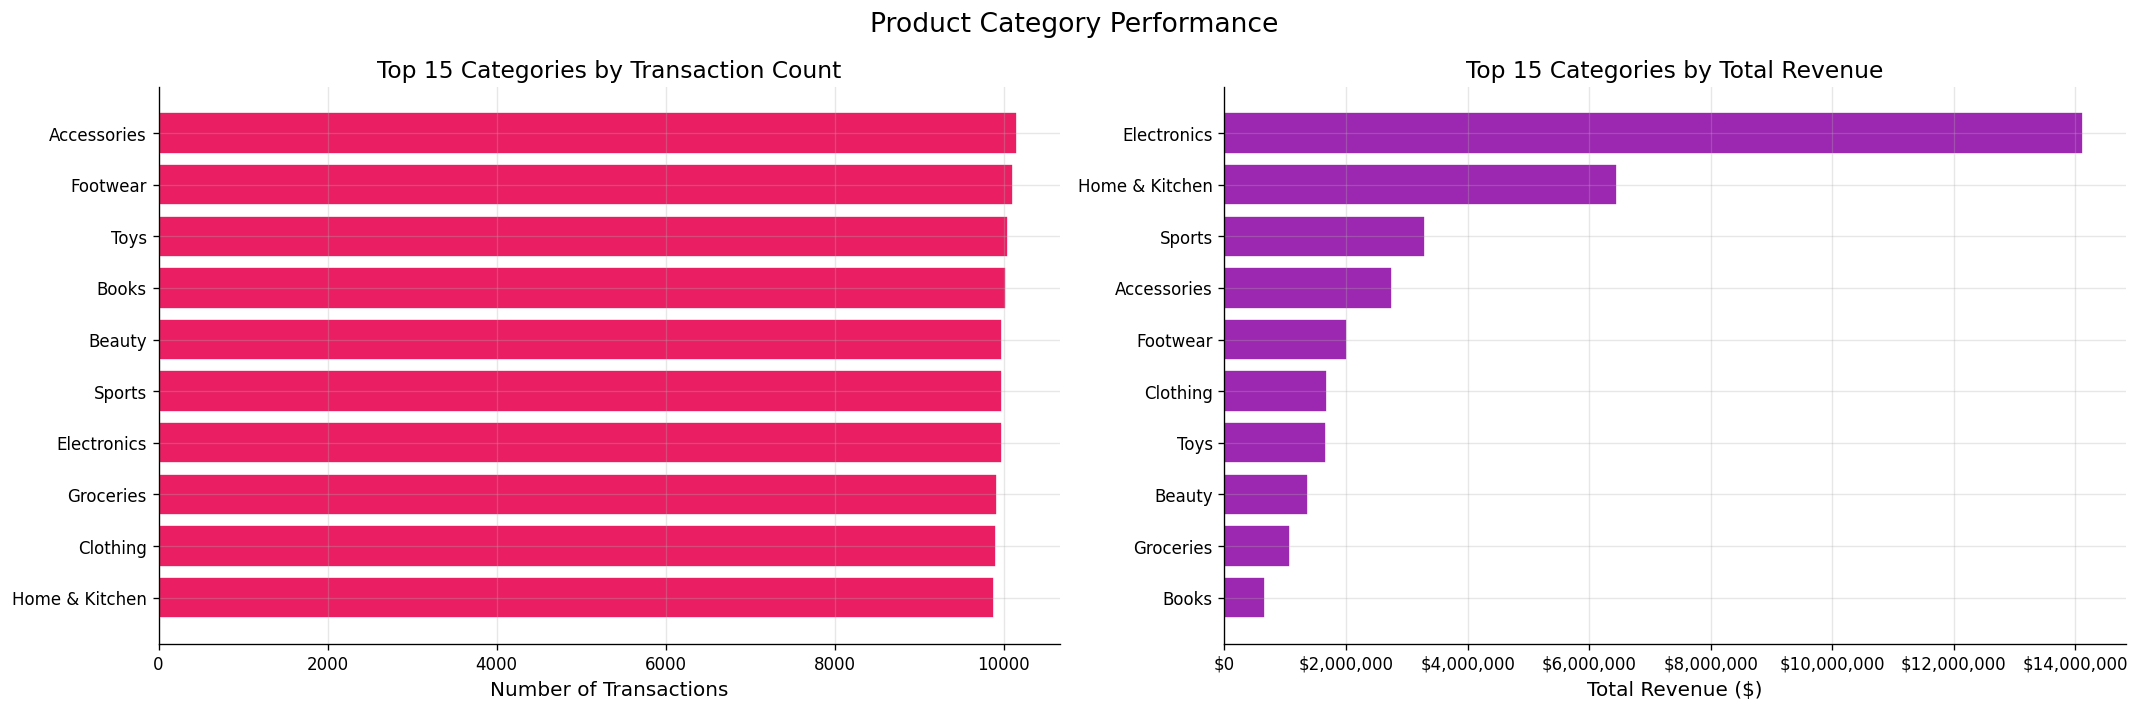


💡 Top 5 Revenue-Generating Categories:
product_category
Electronics      14123441.47
Home & Kitchen    6461099.92
Sports            3303563.29
Accessories       2754561.54
Footwear          2013317.39


In [17]:
# ── Category Distribution & Revenue ──────────────────────────────────────────
if CAT_COL:
    cat_counts = df[CAT_COL].value_counts().head(15)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1],
                 color=COLORS[3], edgecolor='white')
    axes[0].set_title('Top 15 Categories by Transaction Count')
    axes[0].set_xlabel('Number of Transactions')

    if AMT_COL:
        cat_rev = df.groupby(CAT_COL)[AMT_COL].sum().nlargest(15)
        axes[1].barh(cat_rev.index[::-1], cat_rev.values[::-1],
                     color=COLORS[4], edgecolor='white')
        axes[1].set_title('Top 15 Categories by Total Revenue')
        axes[1].set_xlabel('Total Revenue ($)')
        axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    fig.suptitle('Product Category Performance', fontsize=16)
    plt.tight_layout()
    plt.show()

    if AMT_COL:
        print('\n💡 Top 5 Revenue-Generating Categories:')
        print(cat_rev.head(5).to_string())


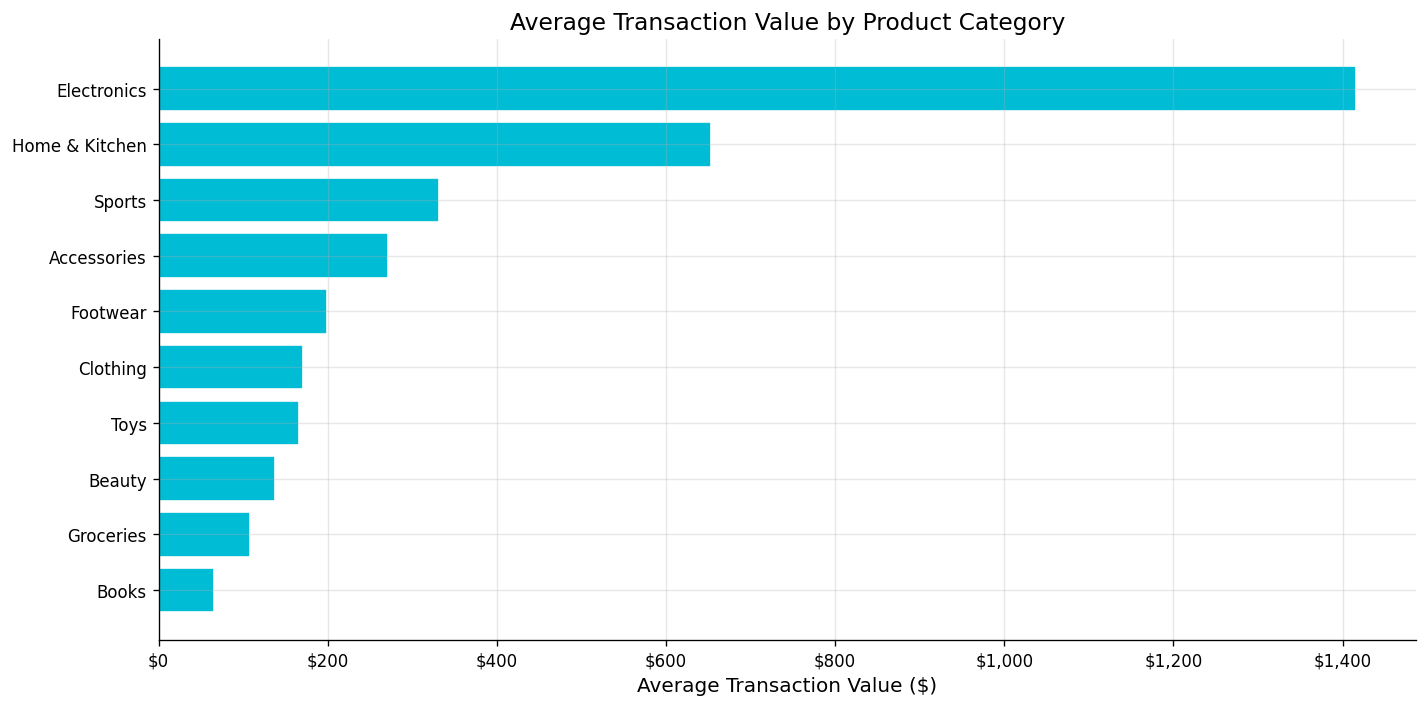

In [18]:
# ── Average Transaction Value by Category ────────────────────────────────────
if CAT_COL and AMT_COL:
    cat_avg = df.groupby(CAT_COL)[AMT_COL].mean().nlargest(15)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(cat_avg.index[::-1], cat_avg.values[::-1],
            color=COLORS[5], edgecolor='white')
    ax.set_title('Average Transaction Value by Product Category')
    ax.set_xlabel('Average Transaction Value ($)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.tight_layout()
    plt.show()


### Pricing & Discount Analysis

One of the most critical questions in Black Friday analytics: do deeper discounts actually generate more revenue, or do they simply erode margins?

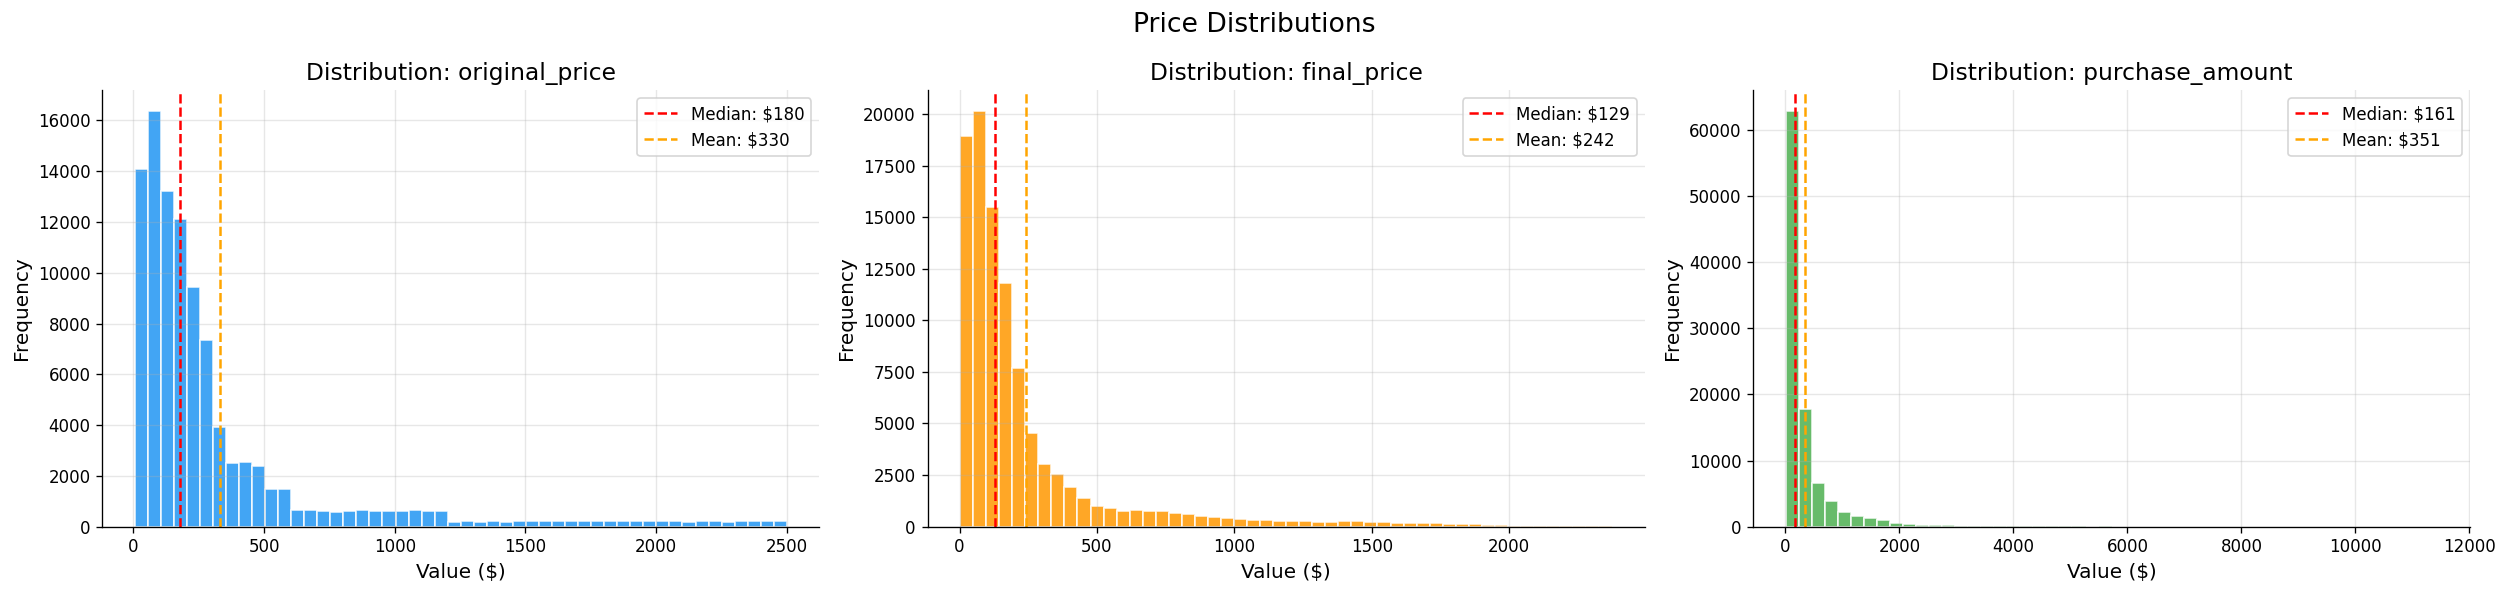

In [19]:
# ── Price Distribution ────────────────────────────────────────────────────────
price_cols = [c for c in [PRICE_COL, FINAL_COL, AMT_COL] if c]
if price_cols:
    n = len(price_cols)
    fig, axes = plt.subplots(1, n, figsize=(7*n, 5))
    if n == 1:
        axes = [axes]

    for i, c in enumerate(price_cols):
        data = df[c].dropna()
        axes[i].hist(data, bins=50, color=COLORS[i], edgecolor='white', alpha=0.85)
        axes[i].axvline(data.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: ${data.median():,.0f}')
        axes[i].axvline(data.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Mean: ${data.mean():,.0f}')
        axes[i].set_title(f'Distribution: {c}')
        axes[i].set_xlabel('Value ($)')
        axes[i].set_ylabel('Frequency')
        axes[i].legend()

    fig.suptitle('Price Distributions', fontsize=16)
    plt.tight_layout()
    plt.show()

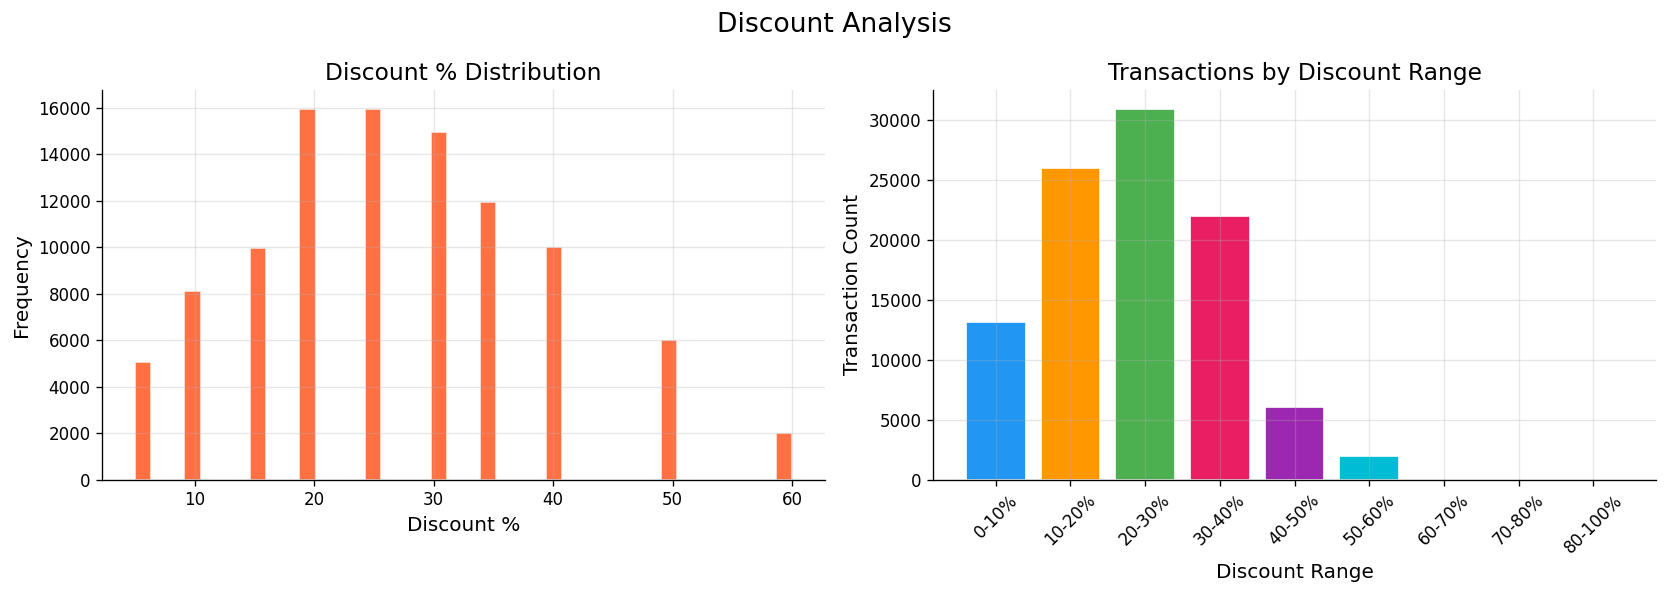

In [20]:
# ── Discount Distribution & Binning ──────────────────────────────────────────
if DISC_COL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(df[DISC_COL].dropna(), bins=40, color=COLORS[6], edgecolor='white', alpha=0.85)
    axes[0].set_title('Discount % Distribution')
    axes[0].set_xlabel('Discount %')
    axes[0].set_ylabel('Frequency')

    # Bin into ranges
    bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 100]
    labels = ['0-10%','10-20%','20-30%','30-40%','40-50%','50-60%','60-70%','70-80%','80-100%']
    df['discount_bin'] = pd.cut(df[DISC_COL], bins=bins, labels=labels, include_lowest=True)

    bin_counts = df['discount_bin'].value_counts().sort_index()
    axes[1].bar(bin_counts.index, bin_counts.values,
                color=COLORS[:len(bin_counts)], edgecolor='white')
    axes[1].set_title('Transactions by Discount Range')
    axes[1].set_xlabel('Discount Range')
    axes[1].set_ylabel('Transaction Count')
    axes[1].tick_params(axis='x', rotation=45)

    fig.suptitle('Discount Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()

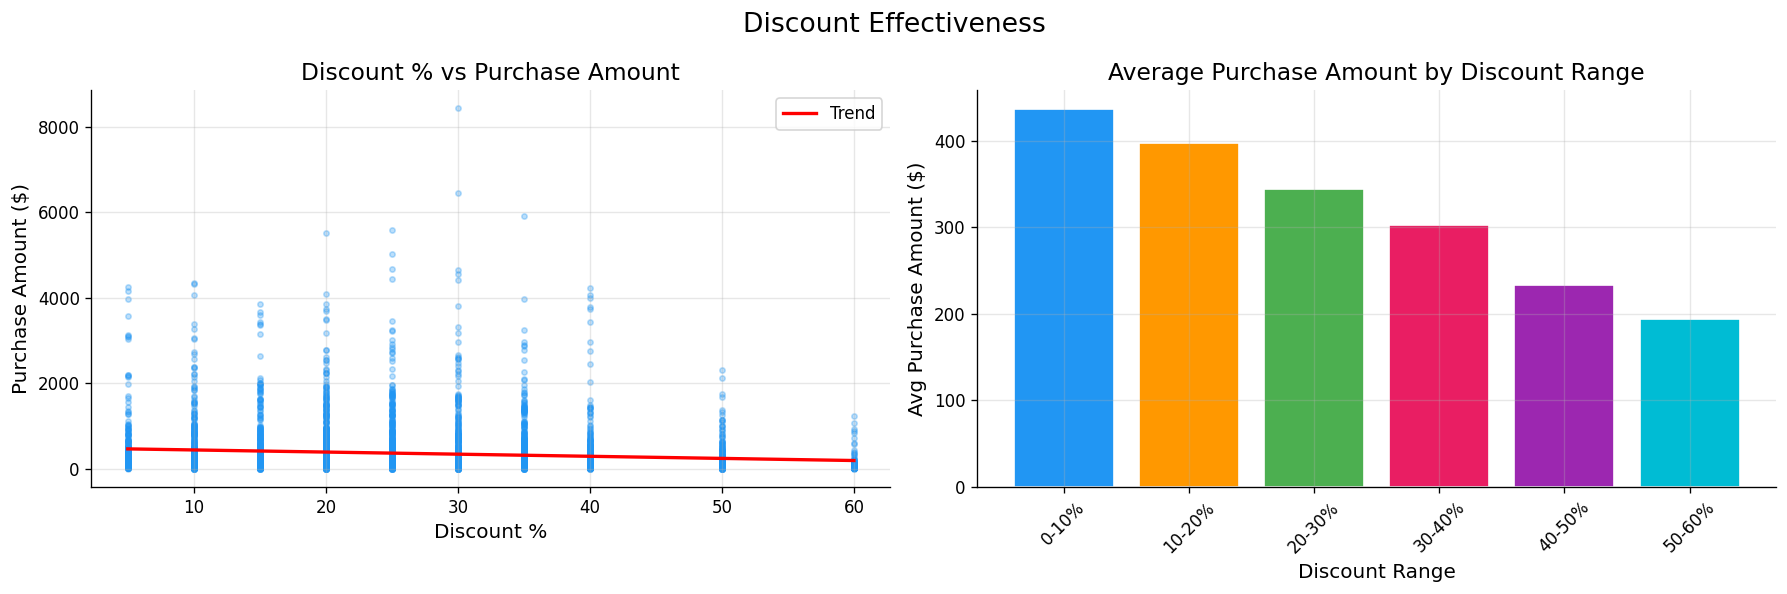


📊 Pearson Correlation (Discount % vs Purchase Amount): -0.1002


In [21]:
# ── Discount vs Revenue (Scatter + Trend) ─────────────────────────────────────
if DISC_COL and AMT_COL:
    sample = df[[DISC_COL, AMT_COL]].dropna().sample(min(5000, len(df)), random_state=42)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].scatter(sample[DISC_COL], sample[AMT_COL],
                    alpha=0.3, color=COLORS[0], s=10)
    # Trend line
    z = np.polyfit(sample[DISC_COL], sample[AMT_COL], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[DISC_COL].min(), sample[DISC_COL].max(), 200)
    axes[0].plot(x_line, p(x_line), color='red', linewidth=2, label='Trend')
    axes[0].set_title('Discount % vs Purchase Amount')
    axes[0].set_xlabel('Discount %')
    axes[0].set_ylabel('Purchase Amount ($)')
    axes[0].legend()

    if 'discount_bin' in df.columns:
        disc_rev = df.groupby('discount_bin', observed=True)[AMT_COL].mean().sort_index()
        axes[1].bar(disc_rev.index, disc_rev.values,
                    color=COLORS[:len(disc_rev)], edgecolor='white')
        axes[1].set_title('Average Purchase Amount by Discount Range')
        axes[1].set_xlabel('Discount Range')
        axes[1].set_ylabel('Avg Purchase Amount ($)')
        axes[1].tick_params(axis='x', rotation=45)

    fig.suptitle('Discount Effectiveness', fontsize=16)
    plt.tight_layout()
    plt.show()

    corr = df[DISC_COL].corr(df[AMT_COL])
    print(f'\n📊 Pearson Correlation (Discount % vs Purchase Amount): {corr:.4f}')

### Revenue & Sales Analysis

In [22]:
# ── Summary Revenue Stats ─────────────────────────────────────────────────────
if AMT_COL:
    total_rev = df[AMT_COL].sum()
    avg_tv    = df[AMT_COL].mean()
    median_tv = df[AMT_COL].median()

    print('=' * 50)
    print('💰 Revenue Summary')
    print('=' * 50)
    print(f'  Total Revenue        : ${total_rev:>15,.2f}')
    print(f'  Avg Transaction Value: ${avg_tv:>15,.2f}')
    print(f'  Median Trans. Value  : ${median_tv:>15,.2f}')
    print(f'  Total Transactions   : {len(df):>15,}')
    if CUST_COL:
        n_cust = df[CUST_COL].nunique()
        print(f'  Unique Customers     : {n_cust:>15,}')
        print(f'  Avg Revenue/Customer : ${total_rev/n_cust:>15,.2f}')

💰 Revenue Summary
  Total Revenue        : $  35,125,630.67
  Avg Transaction Value: $         351.26
  Median Trans. Value  : $         161.15
  Total Transactions   :         100,000
  Unique Customers     :          32,997
  Avg Revenue/Customer : $       1,064.51


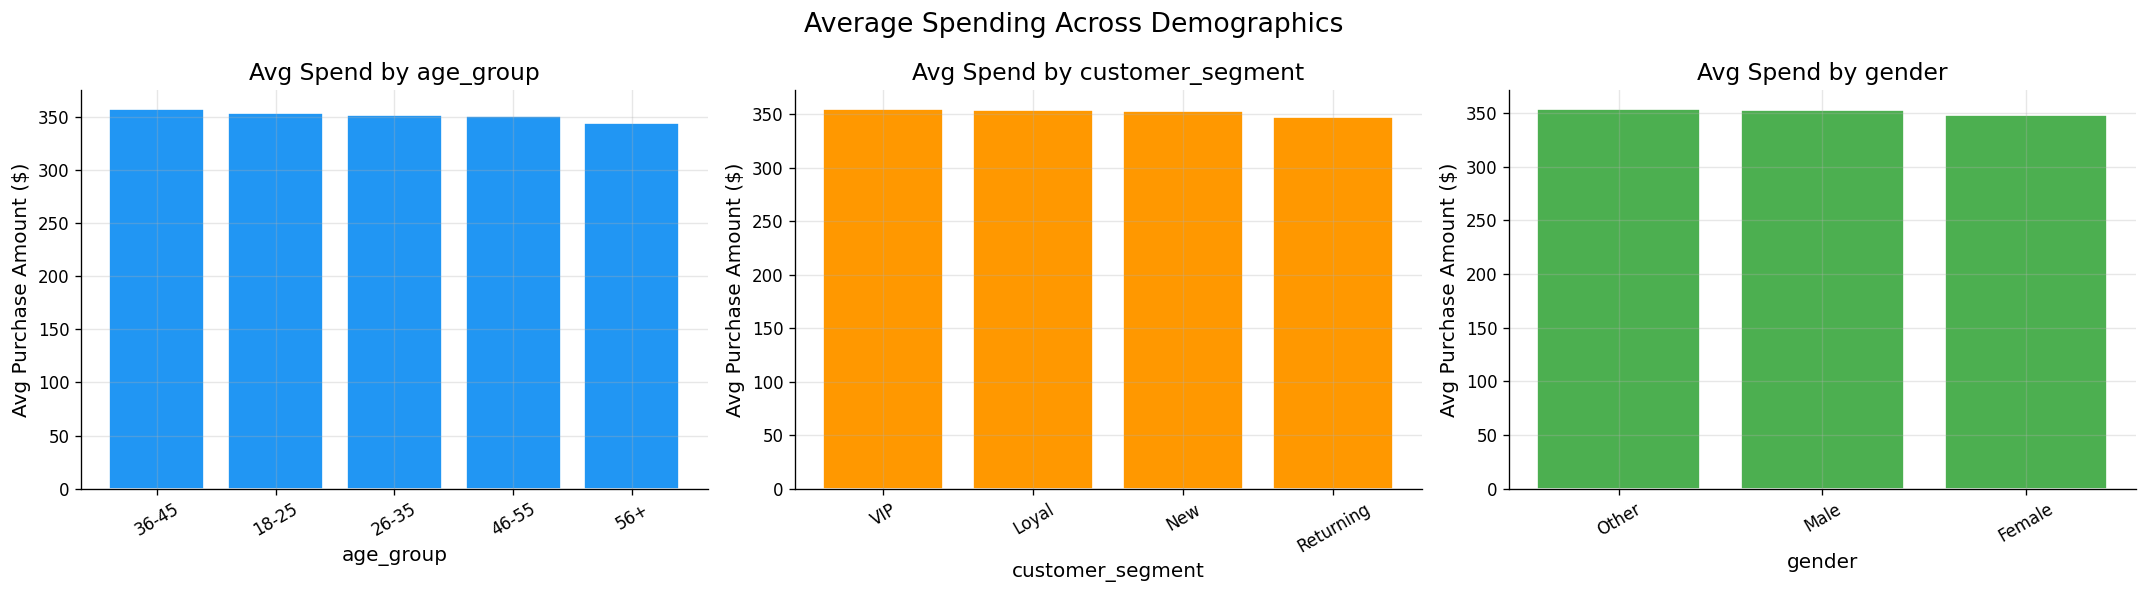

In [23]:
# ── Revenue by Multiple Dimensions ───────────────────────────────────────────
dim_cols = [c for c in [AGE_COL, SEG_COL, GENDER_COL] if c]

if dim_cols and AMT_COL:
    n = len(dim_cols)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1:
        axes = [axes]

    for i, dc in enumerate(dim_cols):
        rev = df.groupby(dc)[AMT_COL].mean().sort_values(ascending=False)
        axes[i].bar(rev.index, rev.values, color=COLORS[i], edgecolor='white')
        axes[i].set_title(f'Avg Spend by {dc}')
        axes[i].set_xlabel(dc)
        axes[i].set_ylabel('Avg Purchase Amount ($)')
        axes[i].tick_params(axis='x', rotation=30)

    fig.suptitle('Average Spending Across Demographics', fontsize=16)
    plt.tight_layout()
    plt.show()

### Time-Based Analysis

Temporal patterns reveal peak shopping hours, day-of-week trends, and the impact of weekends — crucial for staffing, server capacity, and flash-sale timing.

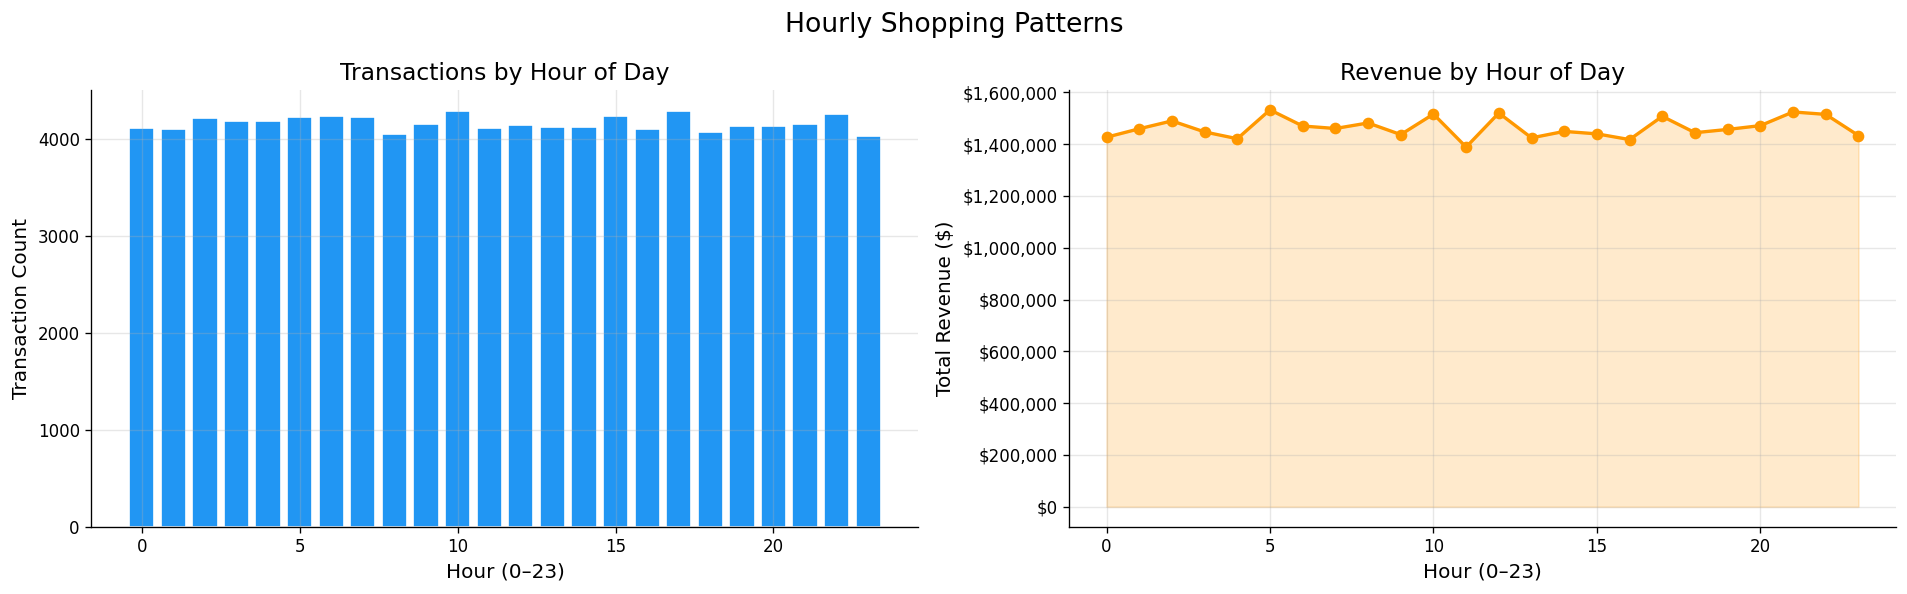


🕐 Peak Shopping Hour: 10:00


In [24]:
# ── Hourly Sales Pattern ──────────────────────────────────────────────────────
if HOUR_COL and AMT_COL:
    hourly = df.groupby(HOUR_COL).agg(
        transactions=(AMT_COL, 'count'),
        revenue=(AMT_COL, 'sum')
    ).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].bar(hourly[HOUR_COL], hourly['transactions'], color=COLORS[0], edgecolor='white')
    axes[0].set_title('Transactions by Hour of Day')
    axes[0].set_xlabel('Hour (0–23)')
    axes[0].set_ylabel('Transaction Count')

    axes[1].plot(hourly[HOUR_COL], hourly['revenue'], marker='o', color=COLORS[1], linewidth=2)
    axes[1].fill_between(hourly[HOUR_COL], hourly['revenue'], alpha=0.2, color=COLORS[1])
    axes[1].set_title('Revenue by Hour of Day')
    axes[1].set_xlabel('Hour (0–23)')
    axes[1].set_ylabel('Total Revenue ($)')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    fig.suptitle('Hourly Shopping Patterns', fontsize=16)
    plt.tight_layout()
    plt.show()

    peak_hour = hourly.loc[hourly['transactions'].idxmax(), HOUR_COL]
    print(f'\n🕐 Peak Shopping Hour: {peak_hour}:00')


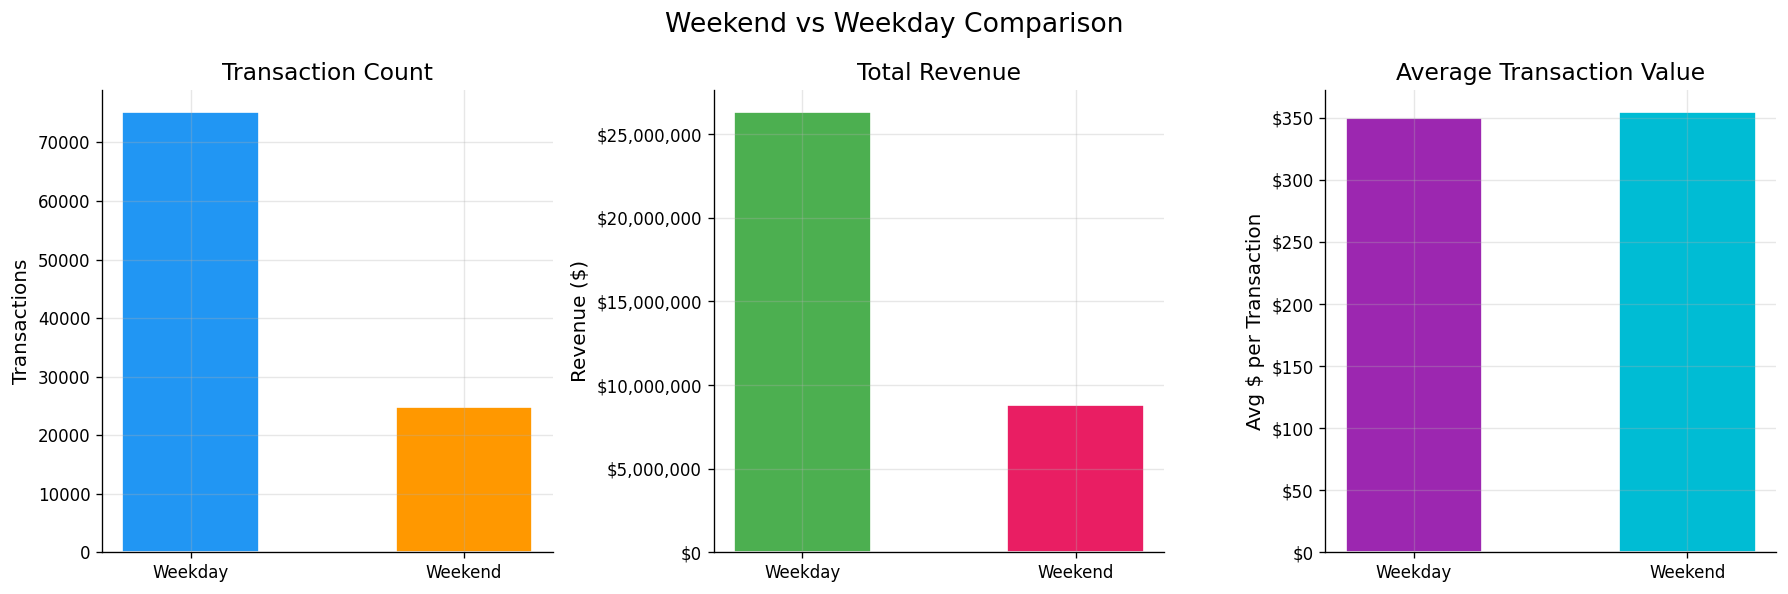

            total_revenue  avg_revenue  count
is_weekend                                   
Weekday       26325138.34       350.12  75189
Weekend        8800492.33       354.70  24811


In [25]:
# ── Weekend vs Weekday ────────────────────────────────────────────────────────
if WEEKEND_COL and AMT_COL:
    wk = df.groupby(WEEKEND_COL).agg(
        total_revenue=(AMT_COL, 'sum'),
        avg_revenue=(AMT_COL, 'mean'),
        count=(AMT_COL, 'count')
    )
    # Map 1/0 or True/False to labels
    try:
        wk.index = wk.index.map({1: 'Weekend', 0: 'Weekday', True: 'Weekend', False: 'Weekday'})
    except Exception:
        pass

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].bar(wk.index, wk['count'], color=COLORS[:2], edgecolor='white', width=0.5)
    axes[0].set_title('Transaction Count')
    axes[0].set_ylabel('Transactions')

    axes[1].bar(wk.index, wk['total_revenue'], color=COLORS[2:4], edgecolor='white', width=0.5)
    axes[1].set_title('Total Revenue')
    axes[1].set_ylabel('Revenue ($)')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    axes[2].bar(wk.index, wk['avg_revenue'], color=COLORS[4:6], edgecolor='white', width=0.5)
    axes[2].set_title('Average Transaction Value')
    axes[2].set_ylabel('Avg $ per Transaction')
    axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    fig.suptitle('Weekend vs Weekday Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()
    print(wk)

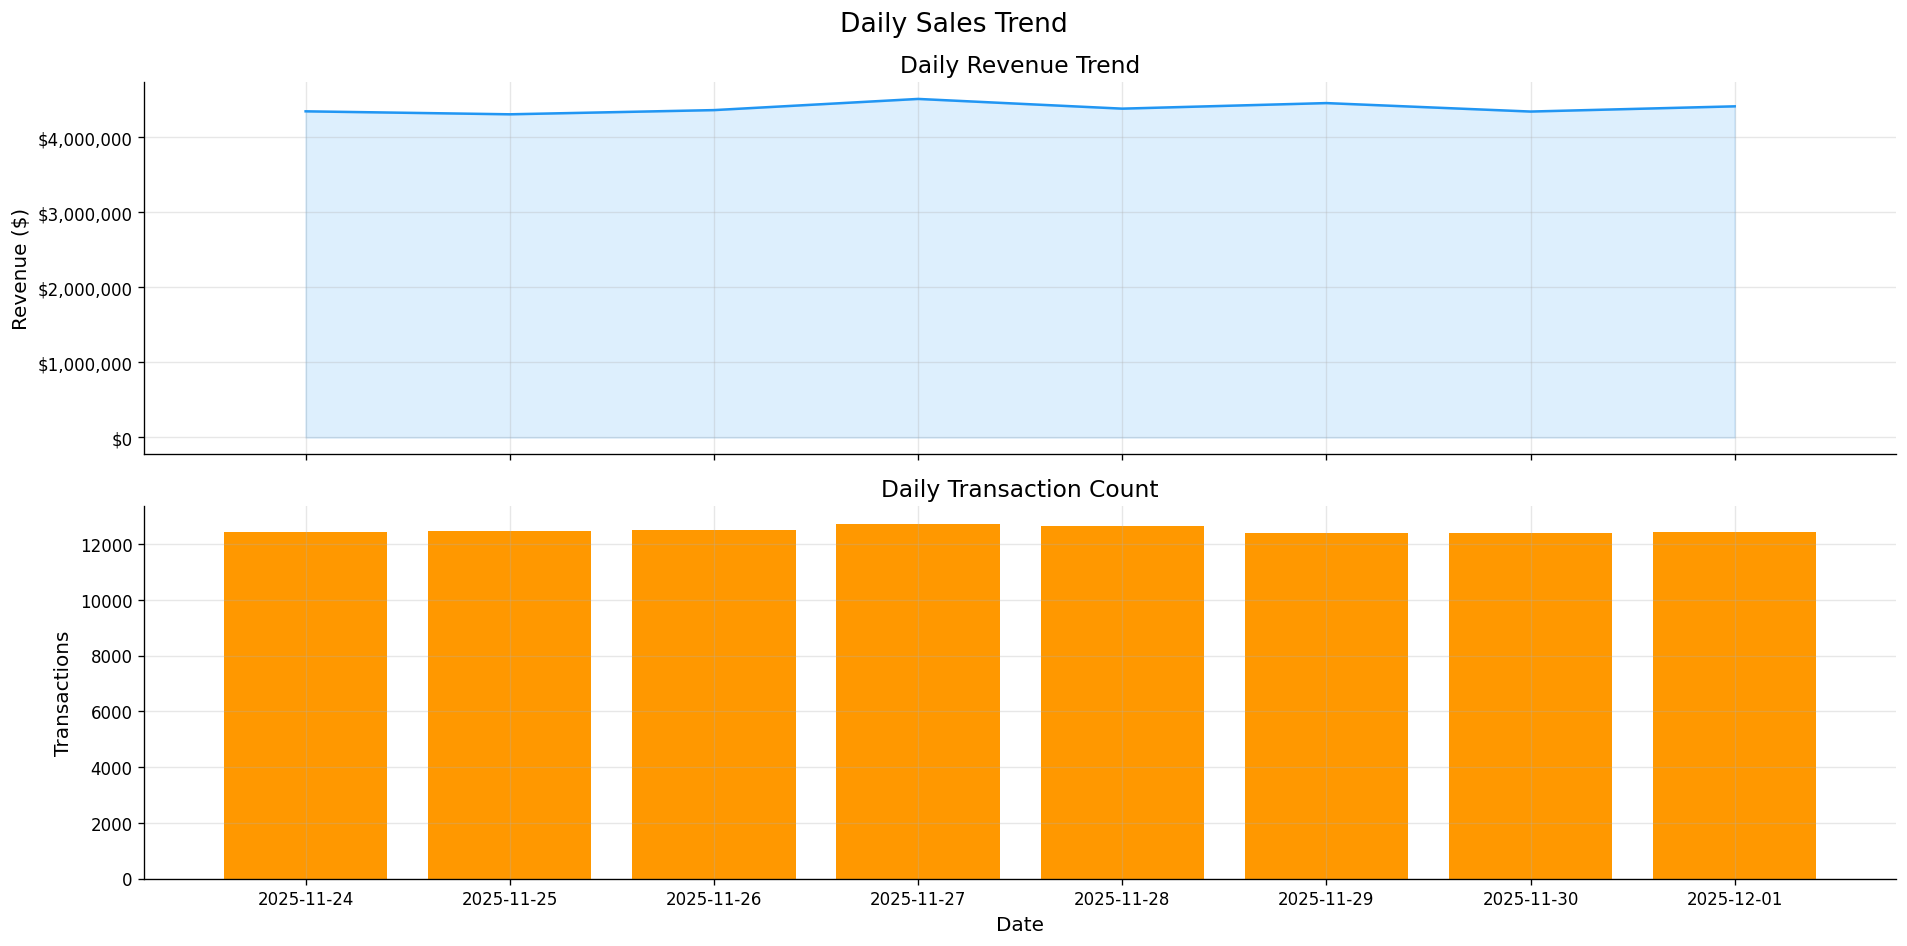

In [26]:
# ── Daily Sales Trend ─────────────────────────────────────────────────────────
if DATE_COL and AMT_COL:
    daily = df.groupby(DATE_COL)[AMT_COL].agg(['sum','count']).reset_index()
    daily.columns = ['date','revenue','transactions']
    daily = daily.sort_values('date')

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

    axes[0].plot(daily['date'], daily['revenue'], color=COLORS[0], linewidth=1.5)
    axes[0].fill_between(daily['date'], daily['revenue'], alpha=0.15, color=COLORS[0])
    axes[0].set_title('Daily Revenue Trend')
    axes[0].set_ylabel('Revenue ($)')
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    axes[1].bar(daily['date'], daily['transactions'], color=COLORS[1], width=0.8)
    axes[1].set_title('Daily Transaction Count')
    axes[1].set_ylabel('Transactions')
    axes[1].set_xlabel('Date')

    fig.suptitle('Daily Sales Trend', fontsize=16)
    plt.tight_layout()
    plt.show()

### Customer Behavior Analysis

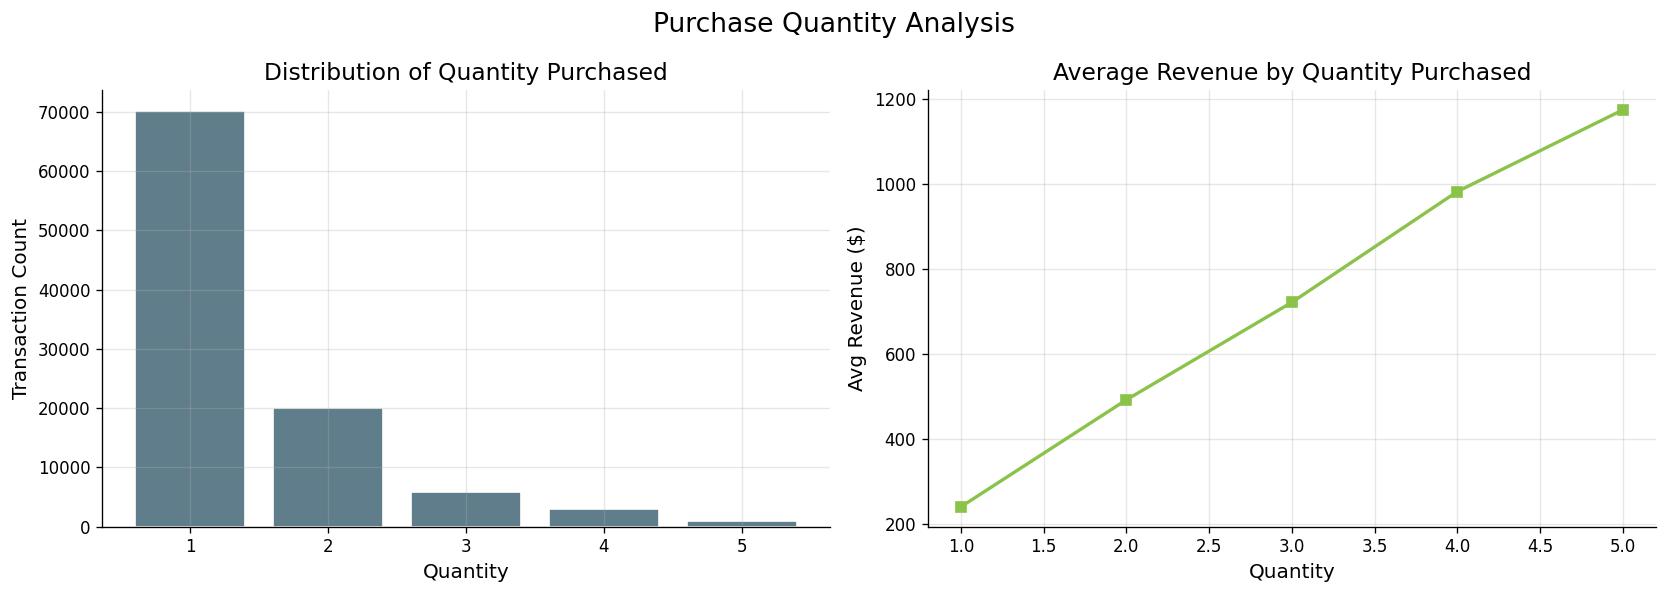

In [27]:
# ── Quantity Analysis ─────────────────────────────────────────────────────────
if QTY_COL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    qty_counts = df[QTY_COL].value_counts().sort_index()
    axes[0].bar(qty_counts.index, qty_counts.values, color=COLORS[7], edgecolor='white')
    axes[0].set_title('Distribution of Quantity Purchased')
    axes[0].set_xlabel('Quantity')
    axes[0].set_ylabel('Transaction Count')

    if AMT_COL:
        qty_rev = df.groupby(QTY_COL)[AMT_COL].mean()
        axes[1].plot(qty_rev.index, qty_rev.values, marker='s', color=COLORS[8], linewidth=2)
        axes[1].set_title('Average Revenue by Quantity Purchased')
        axes[1].set_xlabel('Quantity')
        axes[1].set_ylabel('Avg Revenue ($)')

    fig.suptitle('Purchase Quantity Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()

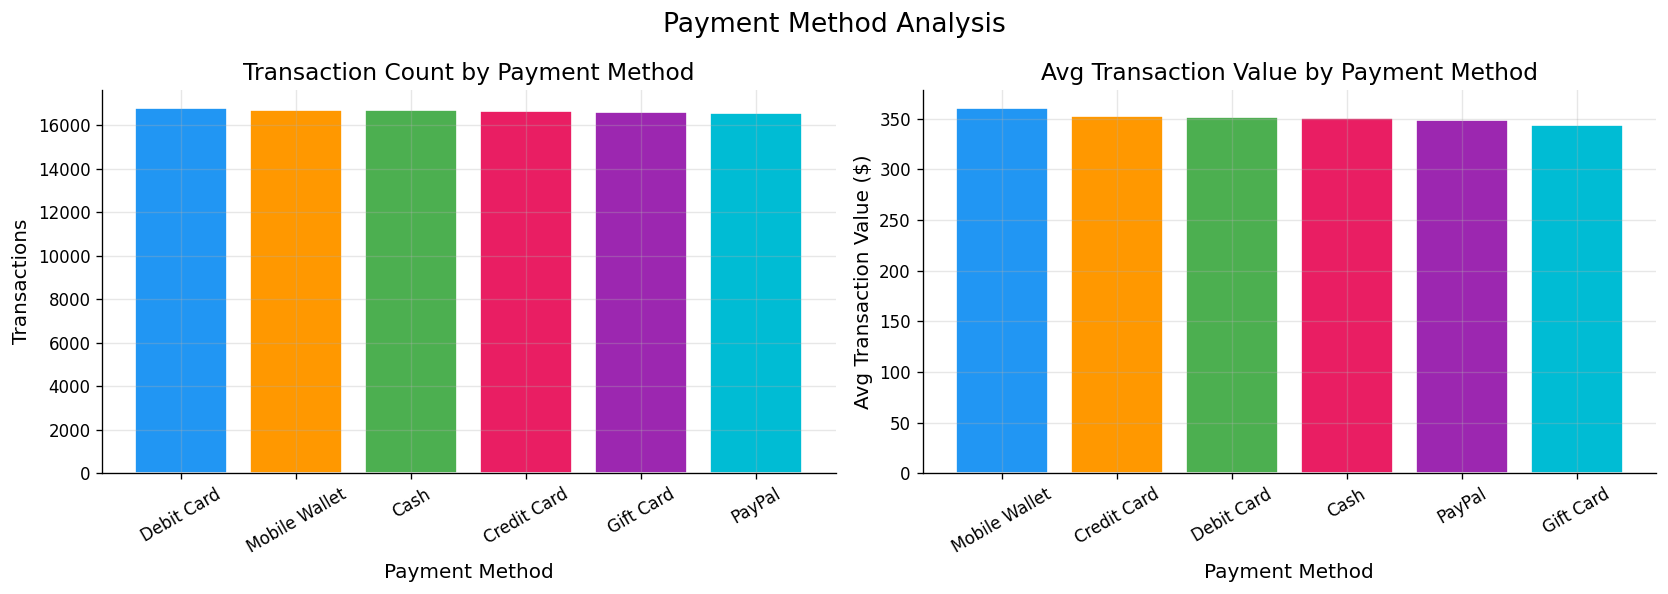

In [28]:
# ── Payment Method Analysis ───────────────────────────────────────────────────
if PAY_COL and AMT_COL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    pay_counts = df[PAY_COL].value_counts()
    axes[0].bar(pay_counts.index, pay_counts.values,
                color=COLORS[:len(pay_counts)], edgecolor='white')
    axes[0].set_title('Transaction Count by Payment Method')
    axes[0].set_xlabel('Payment Method')
    axes[0].set_ylabel('Transactions')
    axes[0].tick_params(axis='x', rotation=30)

    pay_rev = df.groupby(PAY_COL)[AMT_COL].mean().sort_values(ascending=False)
    axes[1].bar(pay_rev.index, pay_rev.values,
                color=COLORS[:len(pay_rev)], edgecolor='white')
    axes[1].set_title('Avg Transaction Value by Payment Method')
    axes[1].set_xlabel('Payment Method')
    axes[1].set_ylabel('Avg Transaction Value ($)')
    axes[1].tick_params(axis='x', rotation=30)

    fig.suptitle('Payment Method Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()


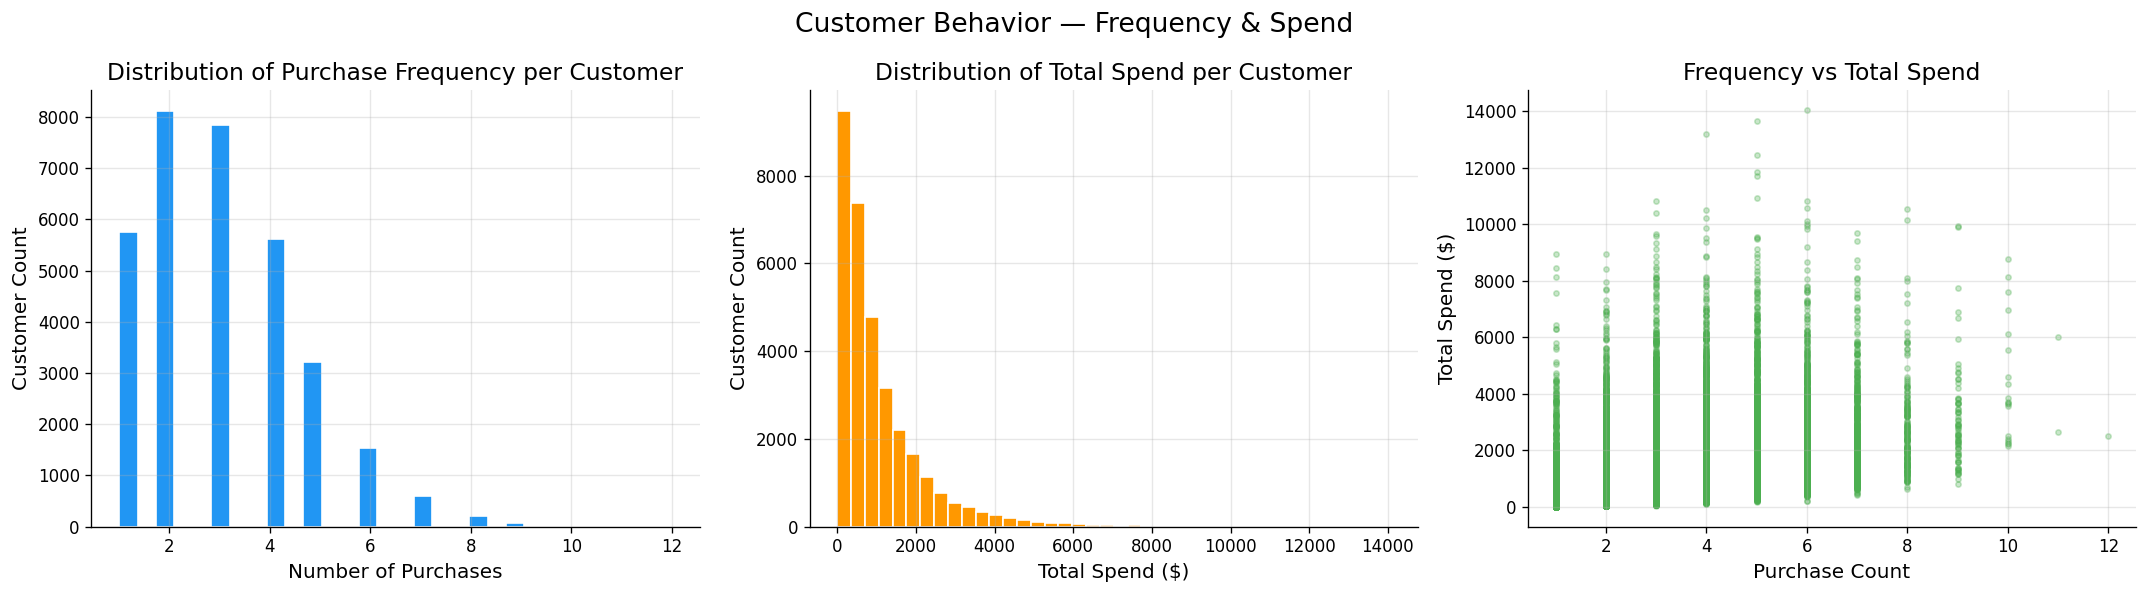


📊 Customer Statistics Summary:
       total_spend  purchase_count  avg_spend
count     32997.00        32997.00   32997.00
mean       1064.51            3.03     350.90
std        1169.17            1.57     396.02
min           2.83            1.00       2.83
25%         306.89            2.00     132.68
50%         685.23            3.00     231.65
75%        1401.71            4.00     425.78
max       14057.64           12.00    8937.40


In [29]:
# ── Repeat Customer Behavior ──────────────────────────────────────────────────
if CUST_COL and AMT_COL:
    cust_stats = df.groupby(CUST_COL).agg(
        total_spend=(AMT_COL, 'sum'),
        purchase_count=(AMT_COL, 'count'),
        avg_spend=(AMT_COL, 'mean')
    ).reset_index()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(cust_stats['purchase_count'], bins=30, color=COLORS[0], edgecolor='white')
    axes[0].set_title('Distribution of Purchase Frequency per Customer')
    axes[0].set_xlabel('Number of Purchases')
    axes[0].set_ylabel('Customer Count')

    axes[1].hist(cust_stats['total_spend'], bins=40, color=COLORS[1], edgecolor='white')
    axes[1].set_title('Distribution of Total Spend per Customer')
    axes[1].set_xlabel('Total Spend ($)')
    axes[1].set_ylabel('Customer Count')

    axes[2].scatter(cust_stats['purchase_count'], cust_stats['total_spend'],
                    alpha=0.3, s=10, color=COLORS[2])
    axes[2].set_title('Frequency vs Total Spend')
    axes[2].set_xlabel('Purchase Count')
    axes[2].set_ylabel('Total Spend ($)')

    fig.suptitle('Customer Behavior — Frequency & Spend', fontsize=16)
    plt.tight_layout()
    plt.show()

    print('\n📊 Customer Statistics Summary:')
    print(cust_stats[['total_spend','purchase_count','avg_spend']].describe().round(2))

### Correlation Analysis

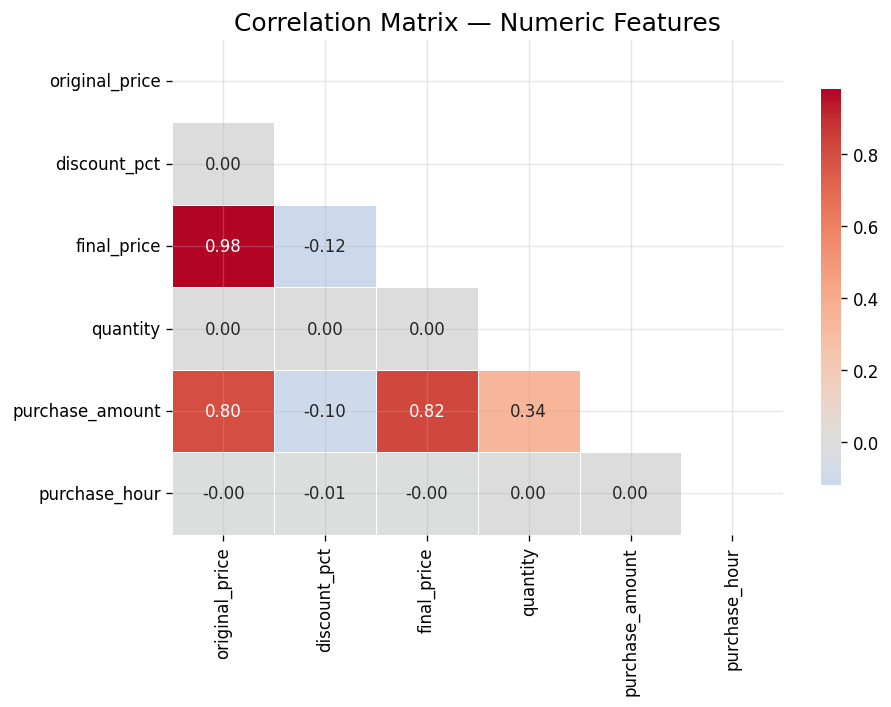


🔗 Top Correlations with "purchase_amount":
final_price      0.82
original_price   0.80
quantity         0.34
discount_pct     0.10
purchase_hour    0.00


In [30]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
num_df = df.select_dtypes(include=[np.number]).copy()
# Drop low-variance or ID-like columns
drop_patt = ['id','index','unnamed','week','month','day','weekday']
keep_cols = [c for c in num_df.columns
             if not any(p in c.lower() for p in drop_patt)]
num_df = num_df[keep_cols]

if num_df.shape[1] >= 2:
    corr_matrix = num_df.corr()

    fig, ax = plt.subplots(figsize=(max(8, len(keep_cols)), max(6, len(keep_cols)-1)))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.2f',
        cmap=CMAP, center=0, linewidths=0.5, ax=ax,
        cbar_kws={'shrink': 0.8}
    )
    ax.set_title('Correlation Matrix — Numeric Features', fontsize=15)
    plt.tight_layout()
    plt.show()

    # Top correlations with AMT_COL
    if AMT_COL and AMT_COL in corr_matrix.columns:
        top_corr = corr_matrix[AMT_COL].drop(AMT_COL).abs().sort_values(ascending=False)
        print(f'\n🔗 Top Correlations with "{AMT_COL}":')
        print(top_corr.head(8).to_string())
else:
    print('⚠️  Not enough numeric columns for a correlation matrix.')

## 🧠  Feature Engineering

We create business-meaningful features that enhance predictive power and enable richer segmentation. Each feature is accompanied by a rationale explaining its business utility.

In [31]:
# ── 7.1 Pricing Features ──────────────────────────────────────────────────────
# discount_amount: monetary value saved per transaction
#   Business use: customers who save more are more discount-sensitive
if PRICE_COL and DISC_COL:
    df['discount_amount'] = df[PRICE_COL] * df[DISC_COL] / 100
    print('✅ discount_amount created')

# effective_discount_rate: actual discount as proportion of original price
#   Business use: normalises across different price points
if PRICE_COL and FINAL_COL:
    df['effective_discount_rate'] = (
        (df[PRICE_COL] - df[FINAL_COL]) / df[PRICE_COL].replace(0, np.nan)
    ).fillna(0)
    print('✅ effective_discount_rate created')

# price_tier: segment products by price range
#   Business use: different marketing strategies per tier
if PRICE_COL:
    p25 = df[PRICE_COL].quantile(0.25)
    p75 = df[PRICE_COL].quantile(0.75)
    df['price_tier'] = pd.cut(
        df[PRICE_COL],
        bins=[-np.inf, p25, p75, np.inf],
        labels=['Budget', 'Mid-Range', 'Premium']
    )
    print('✅ price_tier created')

✅ discount_amount created
✅ effective_discount_rate created
✅ price_tier created


In [32]:
# ── 7.2 Customer Aggregated Features ─────────────────────────────────────────
# customer_total_spend, customer_avg_spend, customer_purchase_freq
#   Business use: input to RFM / customer value models
if CUST_COL and AMT_COL:
    cust_agg = df.groupby(CUST_COL).agg(
        customer_total_spend=(AMT_COL, 'sum'),
        customer_avg_spend=(AMT_COL, 'mean'),
        customer_purchase_freq=(AMT_COL, 'count')
    ).reset_index()
    df = df.merge(cust_agg, on=CUST_COL, how='left')
    print('✅ customer_total_spend, customer_avg_spend, customer_purchase_freq created')

✅ customer_total_spend, customer_avg_spend, customer_purchase_freq created


In [33]:
# ── 7.3 Transaction-Level Features ───────────────────────────────────────────
# revenue_per_item: normalises spend by quantity
#   Business use: identifies high-unit-value vs bulk purchases
if AMT_COL and QTY_COL:
    df['revenue_per_item'] = df[AMT_COL] / df[QTY_COL].replace(0, np.nan)
    df['revenue_per_item'] = df['revenue_per_item'].fillna(0)
    print('✅ revenue_per_item created')

# is_bulk_purchase: flag for quantity > median
if QTY_COL:
    qty_median = df[QTY_COL].median()
    df['is_bulk_purchase'] = (df[QTY_COL] > qty_median).astype(int)
    print(f'✅ is_bulk_purchase created (threshold: qty > {qty_median})')

✅ revenue_per_item created
✅ is_bulk_purchase created (threshold: qty > 1.0)


### Segmentation Features

In [34]:
# spending_category: Low / Medium / High per transaction
if AMT_COL:
    q33 = df[AMT_COL].quantile(0.33)
    q66 = df[AMT_COL].quantile(0.66)
    df['spending_category'] = pd.cut(
        df[AMT_COL],
        bins=[-np.inf, q33, q66, np.inf],
        labels=['Low Spender', 'Medium Spender', 'High Spender']
    )
    print('✅ spending_category created')

# discount_sensitivity_group
if DISC_COL:
    df['discount_sensitivity_group'] = pd.cut(
        df[DISC_COL],
        bins=[-np.inf, 20, 40, 60, np.inf],
        labels=['Low Discount', 'Moderate Discount', 'High Discount', 'Deep Discount']
    )
    print('✅ discount_sensitivity_group created')
# high_value_customer_flag: top 25% by total spend
if 'customer_total_spend' in df.columns:
    threshold = df['customer_total_spend'].quantile(0.75)
    df['high_value_customer'] = (df['customer_total_spend'] >= threshold).astype(int)
    n_hvc = df['high_value_customer'].sum()
    print(f'✅ high_value_customer created (threshold: ${threshold:,.2f}, count: {n_hvc:,})')

print('\n🔑 New Features in DataFrame:')
new_feats = [c for c in df.columns if c not in COLS]
for f in new_feats:
    print(f'  + {f}')

✅ spending_category created
✅ discount_sensitivity_group created
✅ high_value_customer created (threshold: $1,785.48, count: 25,003)

🔑 New Features in DataFrame:
  + purchase_month
  + purchase_day
  + purchase_weekday
  + purchase_week
  + discount_bin
  + discount_amount
  + effective_discount_rate
  + price_tier
  + customer_total_spend
  + customer_avg_spend
  + customer_purchase_freq
  + revenue_per_item
  + is_bulk_purchase
  + spending_category
  + discount_sensitivity_group
  + high_value_customer


## 🤖  Machine Learning


### Task 1 — Predicting Purchase Amount (Regression)¶

We frame purchase amount prediction as a regression problem. Accurate predictions enable dynamic pricing and personalized offer generation.

In [35]:
# ── Feature & Target Selection ────────────────────────────────────────────────
TARGET_REG = AMT_COL

# Candidate features — only use columns that actually exist
candidate_feats = [
    PRICE_COL, DISC_COL, QTY_COL, FINAL_COL,
    AGE_COL, GENDER_COL, SEG_COL, CAT_COL, PAY_COL, CITY_COL,
    HOUR_COL, WEEKEND_COL,
    'discount_amount', 'effective_discount_rate', 'revenue_per_item',
    'customer_purchase_freq', 'is_bulk_purchase',
    'purchase_month', 'purchase_weekday'
]

REG_FEATURES = [f for f in candidate_feats if f and f in df.columns and f != TARGET_REG]

print(f'🎯 Regression Target : {TARGET_REG}')
print(f'📥 Features selected  : {len(REG_FEATURES)}')
for f in REG_FEATURES:
    print(f'  • {f}')

🎯 Regression Target : purchase_amount
📥 Features selected  : 19
  • original_price
  • discount_pct
  • quantity
  • final_price
  • age_group
  • gender
  • customer_segment
  • product_category
  • payment_method
  • city
  • purchase_hour
  • is_weekend
  • discount_amount
  • effective_discount_rate
  • revenue_per_item
  • customer_purchase_freq
  • is_bulk_purchase
  • purchase_month
  • purchase_weekday


In [36]:
# ── Preprocessing ─────────────────────────────────────────────────────────────
df_ml = df[REG_FEATURES + [TARGET_REG]].copy().dropna()

# Encode categoricals
le_dict = {}
for c in df_ml.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_ml[c] = le.fit_transform(df_ml[c].astype(str))
    le_dict[c] = le

# Also encode category-type columns (pd.Categorical)
for c in df_ml.select_dtypes(include='category').columns:
    df_ml[c] = df_ml[c].cat.codes

X = df_ml[REG_FEATURES].values
y = df_ml[TARGET_REG].values

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'📊 Training samples : {X_train.shape[0]:,}')
print(f'📊 Testing samples  : {X_test.shape[0]:,}')

📊 Training samples : 80,000
📊 Testing samples  : 20,000


In [37]:
# ── Model Training & Evaluation ───────────────────────────────────────────────
reg_models = {
    'Linear Regression'         : LinearRegression(),
    'Random Forest Regressor'   : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

reg_results = []
trained_regs = {}

for name, model in reg_models.items():
    X_tr = X_train_sc if name == 'Linear Regression' else X_train
    X_te = X_test_sc  if name == 'Linear Regression' else X_test

    model.fit(X_tr, y_train)
    preds = model.predict(X_te)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    reg_results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    trained_regs[name] = (model, preds)
    print(f'  {name:<35} → MAE: {mae:>10,.2f}  RMSE: {rmse:>10,.2f}  R²: {r2:.4f}')

reg_df = pd.DataFrame(reg_results).sort_values('R²', ascending=False)
print('\n📋 Regression Model Comparison:')
print(reg_df.to_string(index=False))

  Linear Regression                   → MAE:     134.39  RMSE:     275.60  R²: 0.7877
  Random Forest Regressor             → MAE:       0.28  RMSE:       3.33  R²: 1.0000
  Gradient Boosting Regressor         → MAE:       8.15  RMSE:      17.27  R²: 0.9992

📋 Regression Model Comparison:
                      Model    MAE   RMSE   R²
    Random Forest Regressor   0.28   3.33 1.00
Gradient Boosting Regressor   8.15  17.27 1.00
          Linear Regression 134.39 275.60 0.79


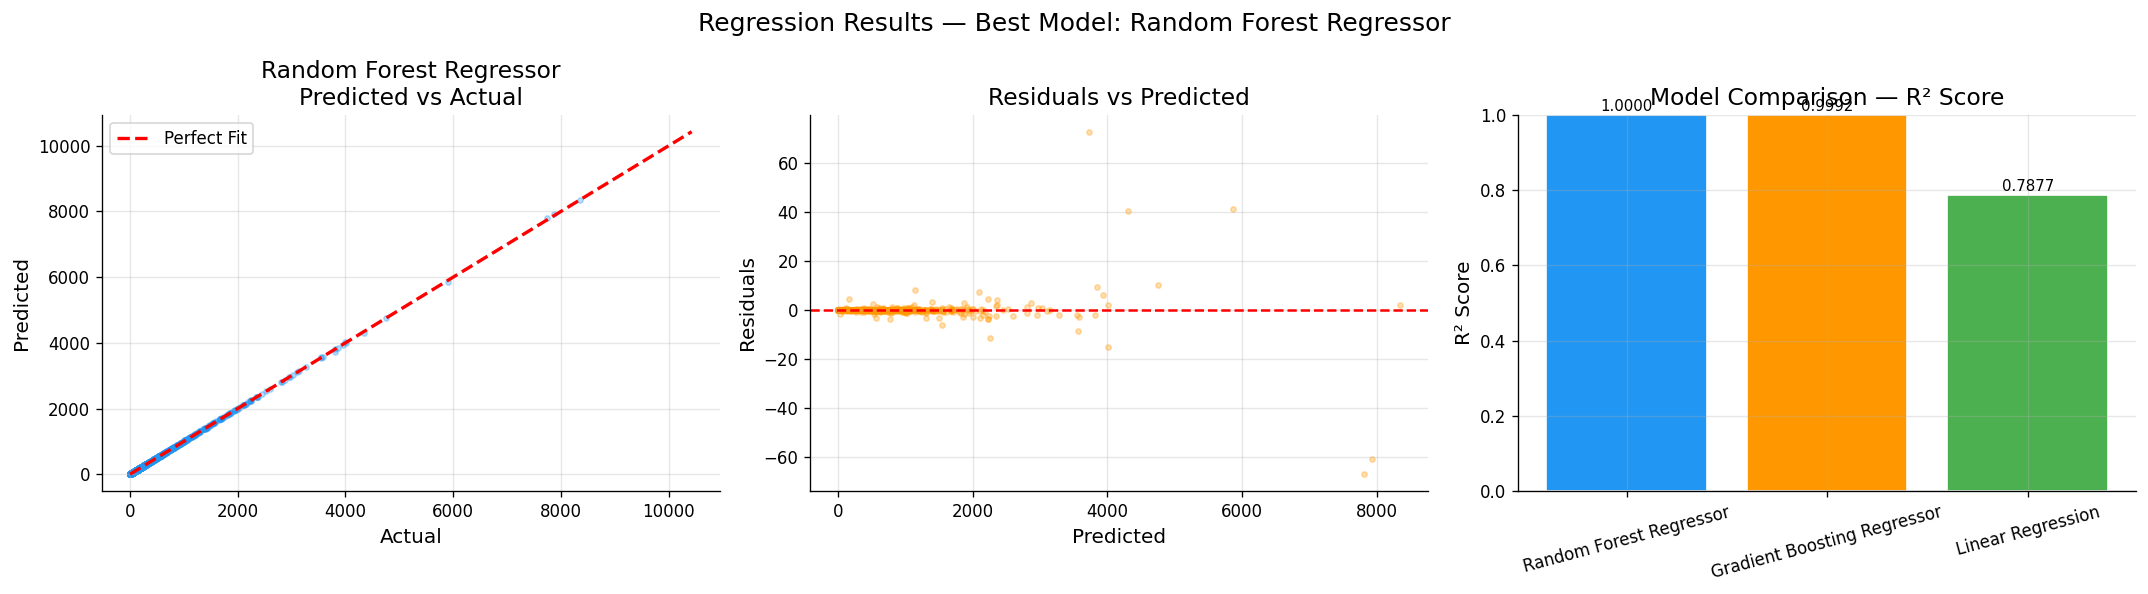

In [38]:
# ── Regression Visualizations ─────────────────────────────────────────────────
best_reg_name = reg_df.iloc[0]['Model']
best_reg_model, best_preds = trained_regs[best_reg_name]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted vs Actual
sample_idx = np.random.choice(len(y_test), min(2000, len(y_test)), replace=False)
axes[0].scatter(y_test[sample_idx], best_preds[sample_idx],
                alpha=0.3, s=10, color=COLORS[0])
mn, mx = min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_title(f'{best_reg_name}\nPredicted vs Actual')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].legend()

# Residuals
residuals = y_test - best_preds
axes[1].scatter(best_preds[sample_idx], residuals[sample_idx],
                alpha=0.3, s=10, color=COLORS[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')

# Model Comparison
colors_bar = [COLORS[i] for i in range(len(reg_df))]
axes[2].bar(reg_df['Model'], reg_df['R²'], color=colors_bar, edgecolor='white')
axes[2].set_title('Model Comparison — R² Score')
axes[2].set_ylabel('R² Score')
axes[2].tick_params(axis='x', rotation=15)
axes[2].set_ylim(0, 1)
for i, v in enumerate(reg_df['R²']):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)

fig.suptitle(f'Regression Results — Best Model: {best_reg_name}', fontsize=15)
plt.tight_layout()
plt.show()

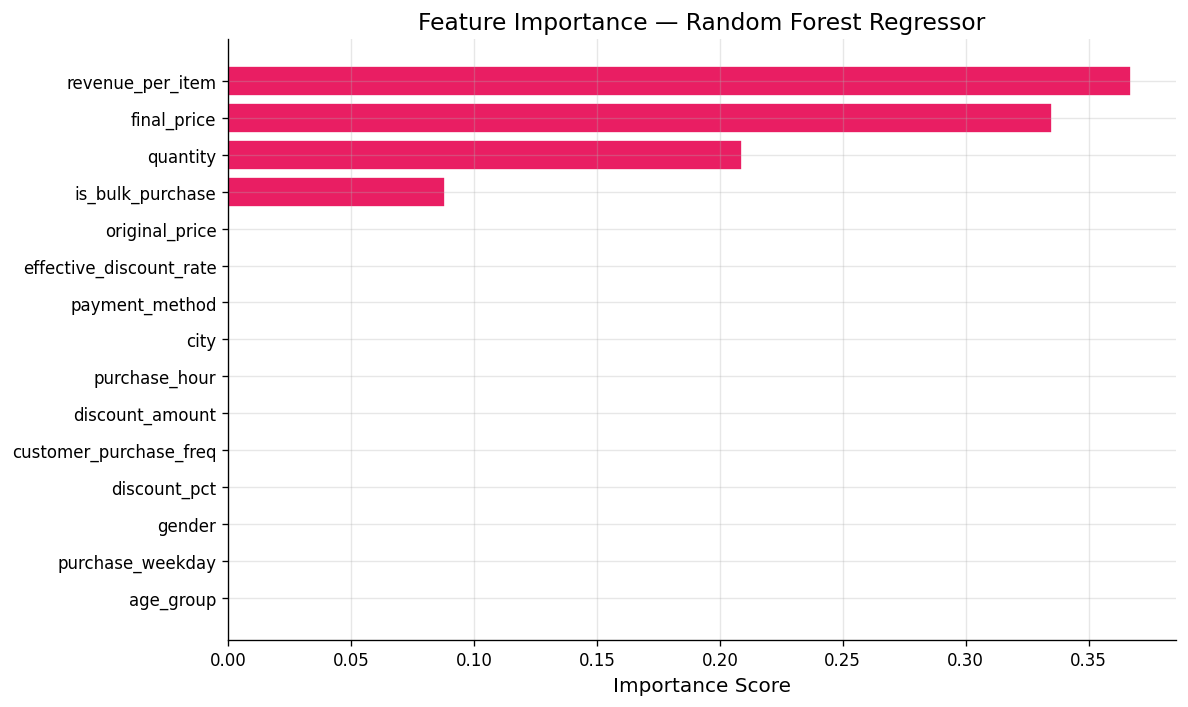

🔑 Top 5 Most Important Features:
revenue_per_item   0.37
final_price        0.34
quantity           0.21
is_bulk_purchase   0.09
original_price     0.00


In [39]:
# ── Feature Importance (RF / GB) ─────────────────────────────────────────────
if hasattr(best_reg_model, 'feature_importances_'):
    fi = pd.Series(best_reg_model.feature_importances_, index=REG_FEATURES)
    fi = fi.sort_values(ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(fi.index, fi.values, color=COLORS[3], edgecolor='white')
    ax.set_title(f'Feature Importance — {best_reg_name}')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
    print('🔑 Top 5 Most Important Features:')
    print(fi.tail(5)[::-1].to_string())

### Task 2 — Predicting High-Value Customers (Classification)¶

Identifying high-value customers before they transact allows for targeted incentives. We train three classifiers and compare performance.

In [40]:
# ── Classification Setup ──────────────────────────────────────────────────────
TARGET_CLF = 'high_value_customer'

if TARGET_CLF not in df.columns:
    # Fallback: create binary target from purchase amount
    if AMT_COL:
        thr = df[AMT_COL].quantile(0.75)
        df[TARGET_CLF] = (df[AMT_COL] >= thr).astype(int)
        print(f'⚠️  Created {TARGET_CLF} from {AMT_COL} >= ${thr:.2f}')

clf_candidate = [
    PRICE_COL, DISC_COL, QTY_COL,
    AGE_COL, GENDER_COL, SEG_COL, CAT_COL, PAY_COL,
    HOUR_COL, WEEKEND_COL,
    'discount_amount', 'effective_discount_rate', 'revenue_per_item',
    'customer_purchase_freq', 'is_bulk_purchase',
    'purchase_month', 'purchase_weekday'
]
CLF_FEATURES = [f for f in clf_candidate if f and f in df.columns and f != TARGET_CLF and f != AMT_COL]

df_clf = df[CLF_FEATURES + [TARGET_CLF]].copy().dropna()
for c in df_clf.select_dtypes(include=['object','category']).columns:
    if c != TARGET_CLF:
        le = LabelEncoder()
        df_clf[c] = le.fit_transform(df_clf[c].astype(str))

X_c = df_clf[CLF_FEATURES].values
y_c = df_clf[TARGET_CLF].values

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)
sc2 = StandardScaler()
X_tr_sc2 = sc2.fit_transform(X_tr_c)
X_te_sc2  = sc2.transform(X_te_c)

print(f'🎯 Classification Target : {TARGET_CLF}')
print(f'📊 Class distribution:\n{pd.Series(y_c).value_counts().to_string()}')

🎯 Classification Target : high_value_customer
📊 Class distribution:
0    74997
1    25003


In [41]:
# ── Classifier Training ───────────────────────────────────────────────────────
clf_models = {
    'Logistic Regression'   : LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree'         : DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest'         : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

clf_results = []
trained_clfs = {}

for name, model in clf_models.items():
    X_tr = X_tr_sc2 if name == 'Logistic Regression' else X_tr_c
    X_te = X_te_sc2 if name == 'Logistic Regression' else X_te_c

    model.fit(X_tr, y_tr_c)
    preds = model.predict(X_te)

    acc  = accuracy_score(y_te_c, preds)
    prec = precision_score(y_te_c, preds, zero_division=0)
    rec  = recall_score(y_te_c, preds, zero_division=0)
    f1   = f1_score(y_te_c, preds, zero_division=0)

    clf_results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    trained_clfs[name] = (model, preds)
    print(f'  {name:<25} → Acc: {acc:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  F1: {f1:.4f}')

clf_df = pd.DataFrame(clf_results).sort_values('F1', ascending=False)
print('\n📋 Classifier Comparison:')
print(clf_df.to_string(index=False))

  Logistic Regression       → Acc: 0.8067  Prec: 0.6918  Rec: 0.4093  F1: 0.5143
  Decision Tree             → Acc: 0.8127  Prec: 0.7334  Rec: 0.3943  F1: 0.5129
  Random Forest             → Acc: 0.8099  Prec: 0.7152  Rec: 0.3987  F1: 0.5120

📋 Classifier Comparison:
              Model  Accuracy  Precision  Recall   F1
Logistic Regression      0.81       0.69    0.41 0.51
      Decision Tree      0.81       0.73    0.39 0.51
      Random Forest      0.81       0.72    0.40 0.51


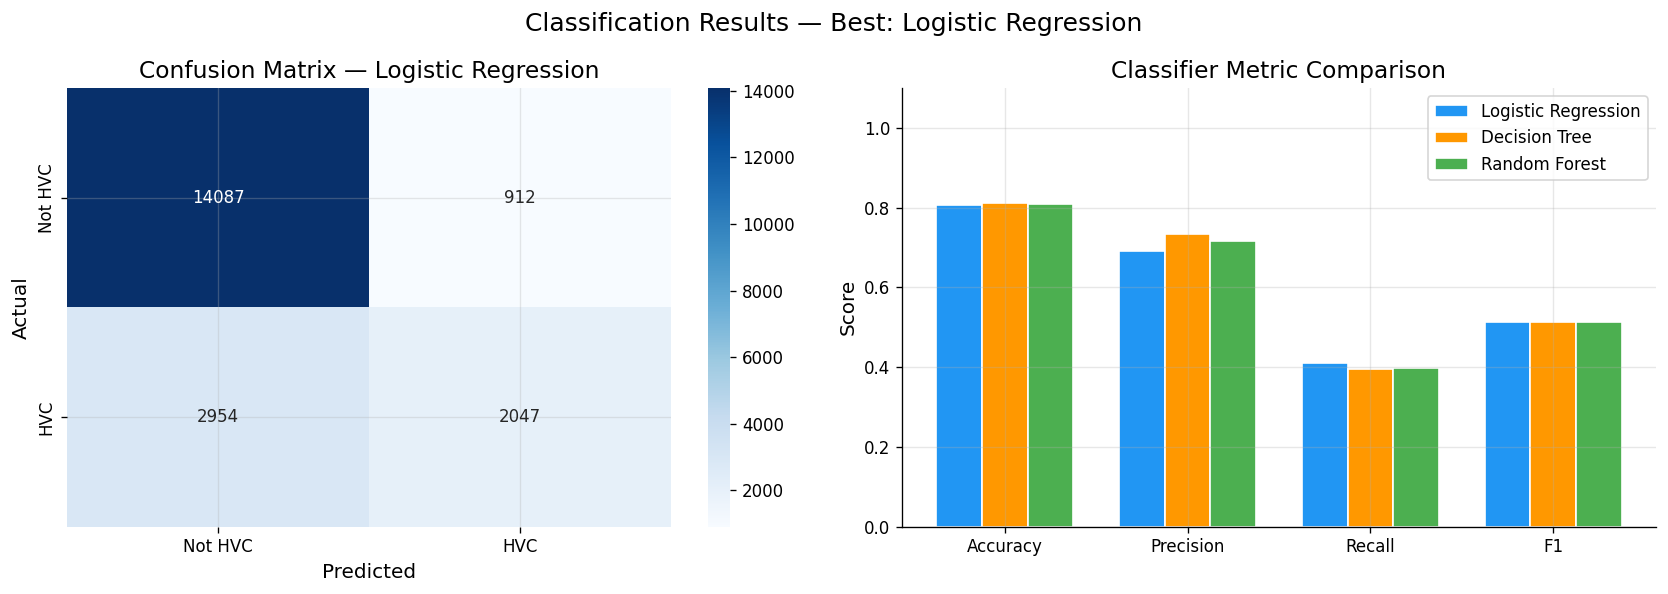


📄 Classification Report — Logistic Regression:
              precision    recall  f1-score   support

     Not HVC       0.83      0.94      0.88     14999
         HVC       0.69      0.41      0.51      5001

    accuracy                           0.81     20000
   macro avg       0.76      0.67      0.70     20000
weighted avg       0.79      0.81      0.79     20000



In [42]:
# ── Confusion Matrix & Metrics Plot ──────────────────────────────────────────
best_clf_name = clf_df.iloc[0]['Model']
best_clf_model, best_clf_preds = trained_clfs[best_clf_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_te_c, best_clf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not HVC', 'HVC'],
            yticklabels=['Not HVC', 'HVC'])
axes[0].set_title(f'Confusion Matrix — {best_clf_name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Metric Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.25
for i, row in clf_df.iterrows():
    vals = [row[m] for m in metrics]
    offset = (list(clf_df.index).index(i) - 1) * width
    axes[1].bar(x + offset, vals, width, label=row['Model'],
                color=COLORS[list(clf_df.index).index(i)], edgecolor='white')
axes[1].set_title('Classifier Metric Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.1)
axes[1].legend()

fig.suptitle(f'Classification Results — Best: {best_clf_name}', fontsize=15)
plt.tight_layout()
plt.show()

print(f'\n📄 Classification Report — {best_clf_name}:')
print(classification_report(y_te_c, best_clf_preds, target_names=['Not HVC','HVC']))

In [43]:
# ── Feature Importance (Classification) ──────────────────────────────────────
if hasattr(best_clf_model, 'feature_importances_'):
    fi_c = pd.Series(best_clf_model.feature_importances_, index=CLF_FEATURES)
    fi_c = fi_c.sort_values(ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(fi_c.index, fi_c.values, color=COLORS[5], edgecolor='white')
    ax.set_title(f'Feature Importance — {best_clf_name} (Classification)')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

## 🔍  Advanced Analysis

### Customer Segmentation with K-Means Clustering¶

K-Means clusters customers into behavioral groups based on spending, discount response, and purchase frequency. These clusters power personalized marketing strategies.

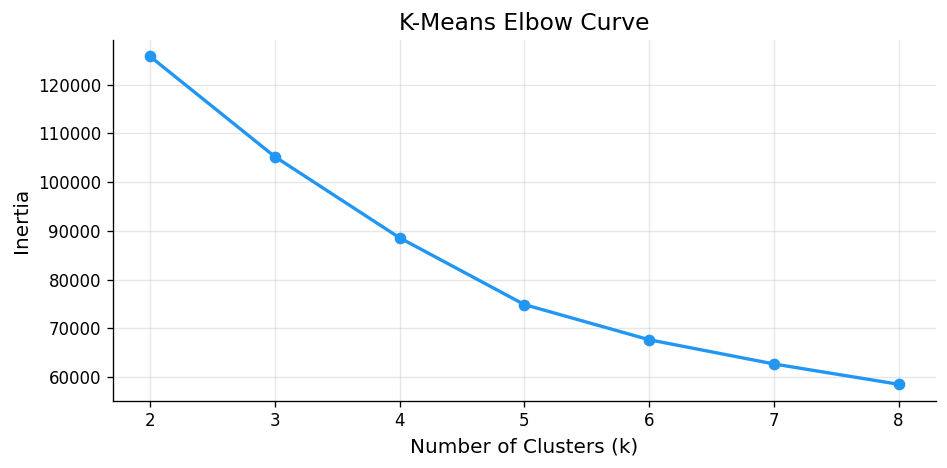

In [44]:
# ── Prepare Clustering Features ───────────────────────────────────────────────
cluster_feat_candidates = [
    'customer_total_spend', 'customer_avg_spend', 'customer_purchase_freq',
    DISC_COL, QTY_COL
]
cluster_feats = [f for f in cluster_feat_candidates if f and f in df.columns]

if len(cluster_feats) >= 2 and CUST_COL:
    # Get one row per customer
    cust_cluster = df.groupby(CUST_COL)[cluster_feats].mean().dropna().reset_index()
    X_clust = cust_cluster[cluster_feats].values
    scaler_c = StandardScaler()
    X_clust_sc = scaler_c.fit_transform(X_clust)

    # Elbow Method
    inertias = []
    K_range = range(2, 9)
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_clust_sc)
        inertias.append(km.inertia_)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(K_range, inertias, marker='o', color=COLORS[0], linewidth=2)
    ax.set_title('K-Means Elbow Curve')
    ax.set_xlabel('Number of Clusters (k)')
    ax.set_ylabel('Inertia')
    plt.tight_layout()
    plt.show()
else:
  print('⚠️  Not enough features for clustering. Skipping.')
  X_clust_sc = None

📊 Cluster Profiles:
         customer_total_spend  customer_avg_spend  customer_purchase_freq  discount_pct  quantity
cluster                                                                                          
0                     1505.62              330.64                    4.73         26.51      1.41
1                      734.67              362.06                    2.05         27.28      2.36
2                     4078.52             1392.32                    3.39         24.59      1.87
3                      453.09              214.75                    2.17         26.84      1.14


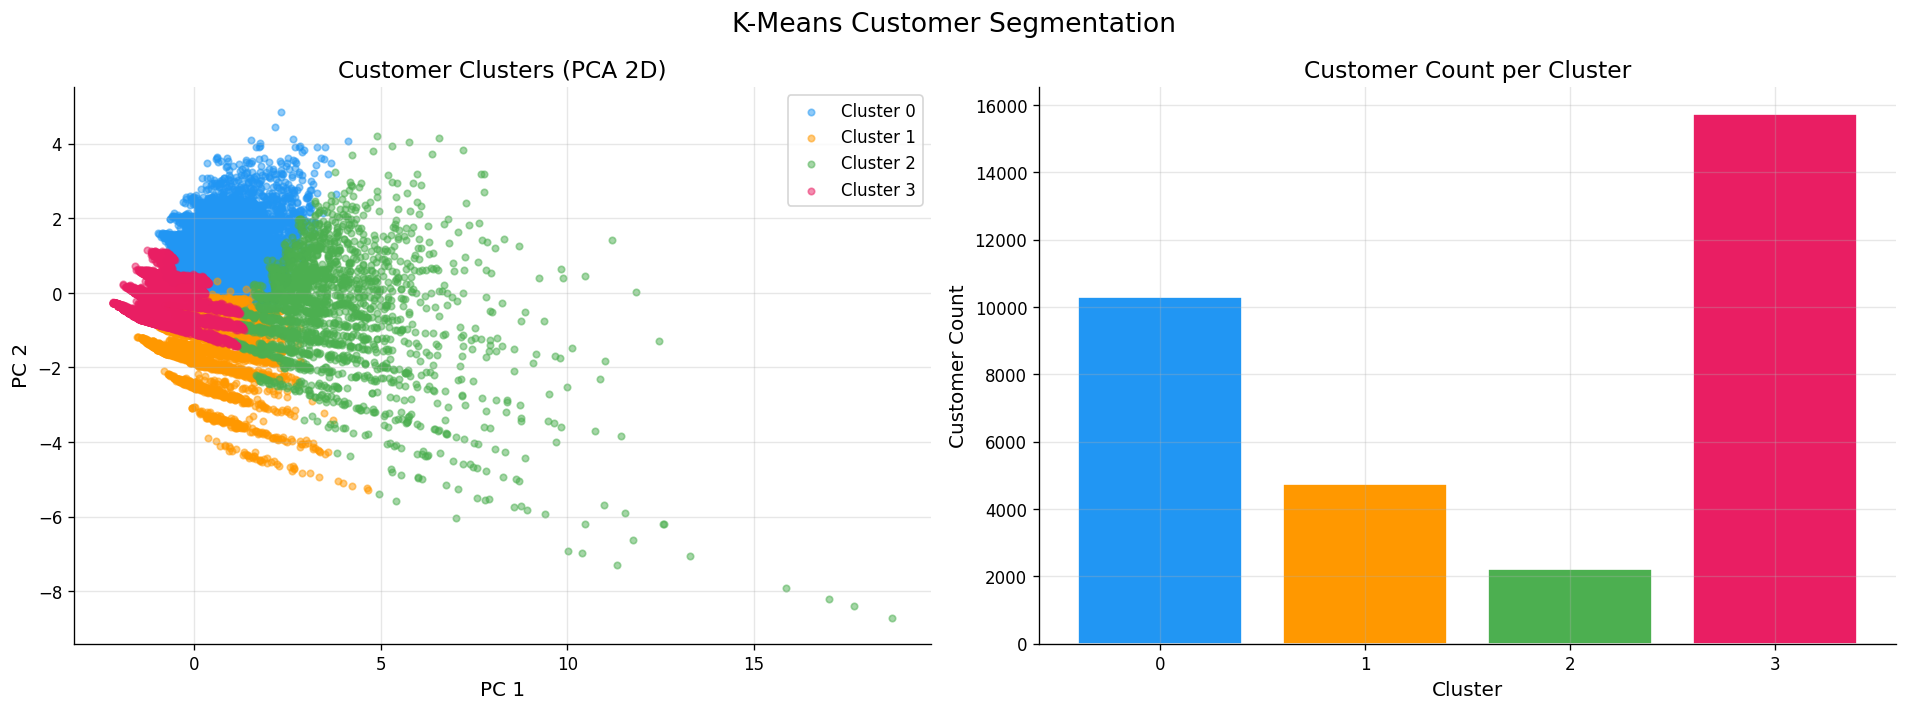

In [45]:
# ── Fit K-Means with k=4 ────────────────────────────────────────────────────
if X_clust_sc is not None:
    k = 4
    km_final = KMeans(n_clusters=k, random_state=42, n_init=10)
    cust_cluster['cluster'] = km_final.fit_predict(X_clust_sc)

    # Profile each cluster
    cluster_profile = cust_cluster.groupby('cluster')[cluster_feats].mean().round(2)
    print('📊 Cluster Profiles:')
    print(cluster_profile.to_string())

    # ── PCA for 2D visualization ──────────────────────────────────────────────
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_clust_sc)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for cl in range(k):
        mask = cust_cluster['cluster'] == cl
        axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                        s=15, alpha=0.5, label=f'Cluster {cl}', color=COLORS[cl])
    axes[0].set_title('Customer Clusters (PCA 2D)')
    axes[0].set_xlabel('PC 1')
    axes[0].set_ylabel('PC 2')
    axes[0].legend()
    cluster_counts = cust_cluster['cluster'].value_counts().sort_index()
    axes[1].bar(cluster_counts.index.astype(str), cluster_counts.values,
                color=COLORS[:k], edgecolor='white')
    axes[1].set_title('Customer Count per Cluster')
    axes[1].set_xlabel('Cluster')
    axes[1].set_ylabel('Customer Count')

    fig.suptitle('K-Means Customer Segmentation', fontsize=16)
    plt.tight_layout()
    plt.show()


### Discount Effectiveness Deep Dive

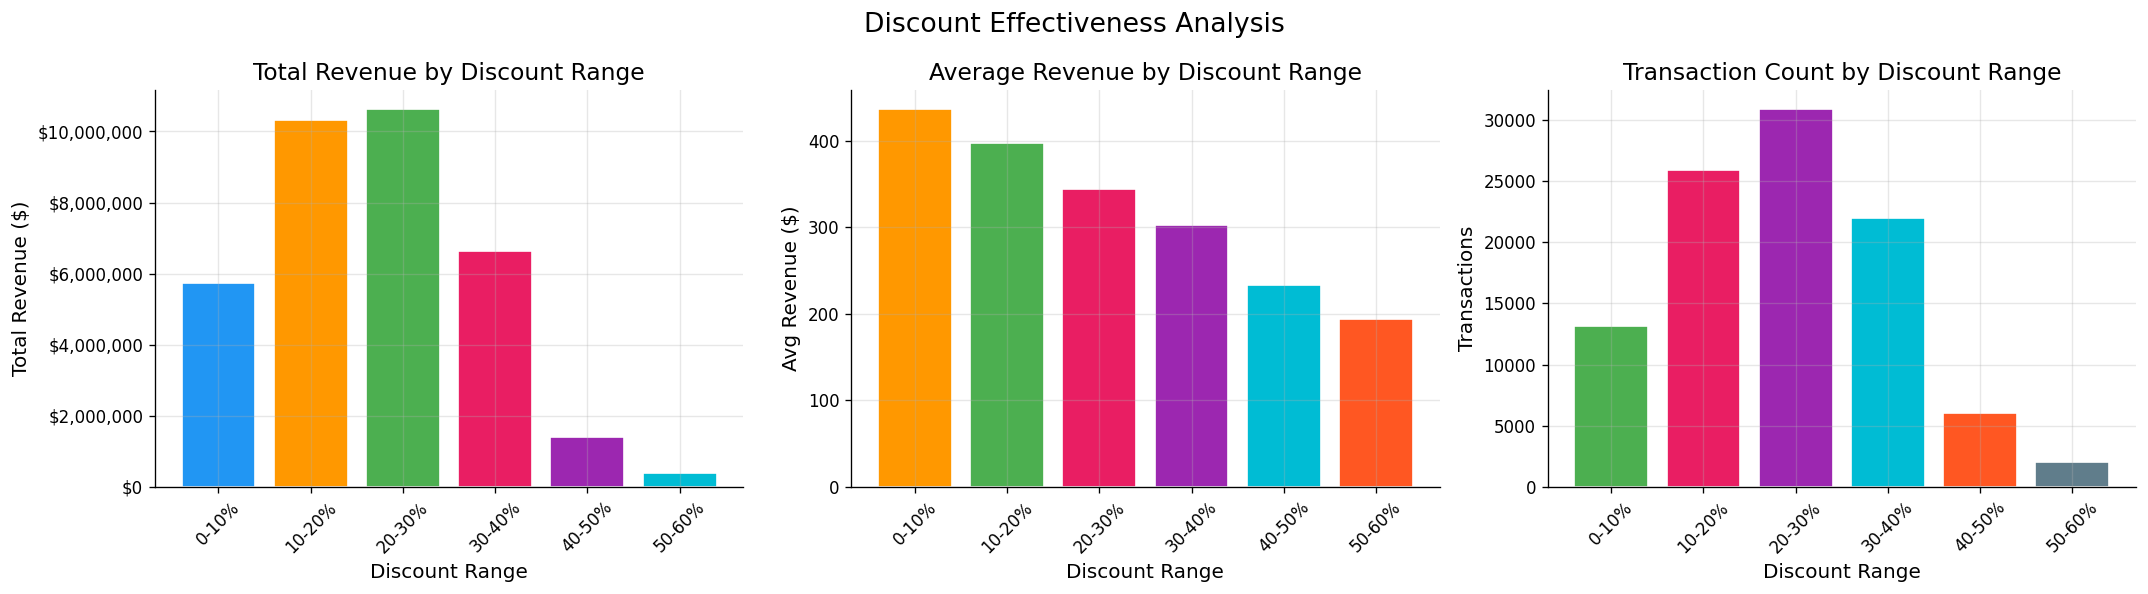

In [46]:
# ── Revenue by Discount Range & Category ─────────────────────────────────────
if DISC_COL and AMT_COL and 'discount_bin' in df.columns:
    disc_summary = df.groupby('discount_bin', observed=True).agg(
        total_revenue=(AMT_COL, 'sum'),
        avg_revenue=(AMT_COL, 'mean'),
        transaction_count=(AMT_COL, 'count')
    ).reset_index()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].bar(disc_summary['discount_bin'], disc_summary['total_revenue'],
                color=COLORS[:len(disc_summary)], edgecolor='white')
    axes[0].set_title('Total Revenue by Discount Range')
    axes[0].set_xlabel('Discount Range')
    axes[0].set_ylabel('Total Revenue ($)')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    axes[1].bar(disc_summary['discount_bin'], disc_summary['avg_revenue'],
                color=COLORS[1:], edgecolor='white')
    axes[1].set_title('Average Revenue by Discount Range')
    axes[1].set_xlabel('Discount Range')
    axes[1].set_ylabel('Avg Revenue ($)')
    axes[1].tick_params(axis='x', rotation=45)

    axes[2].bar(disc_summary['discount_bin'], disc_summary['transaction_count'],
                color=COLORS[2:], edgecolor='white')
    axes[2].set_title('Transaction Count by Discount Range')
    axes[2].set_xlabel('Discount Range')
    axes[2].set_ylabel('Transactions')
    axes[2].tick_params(axis='x', rotation=45)

    fig.suptitle('Discount Effectiveness Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()

### Category Performance Matrix

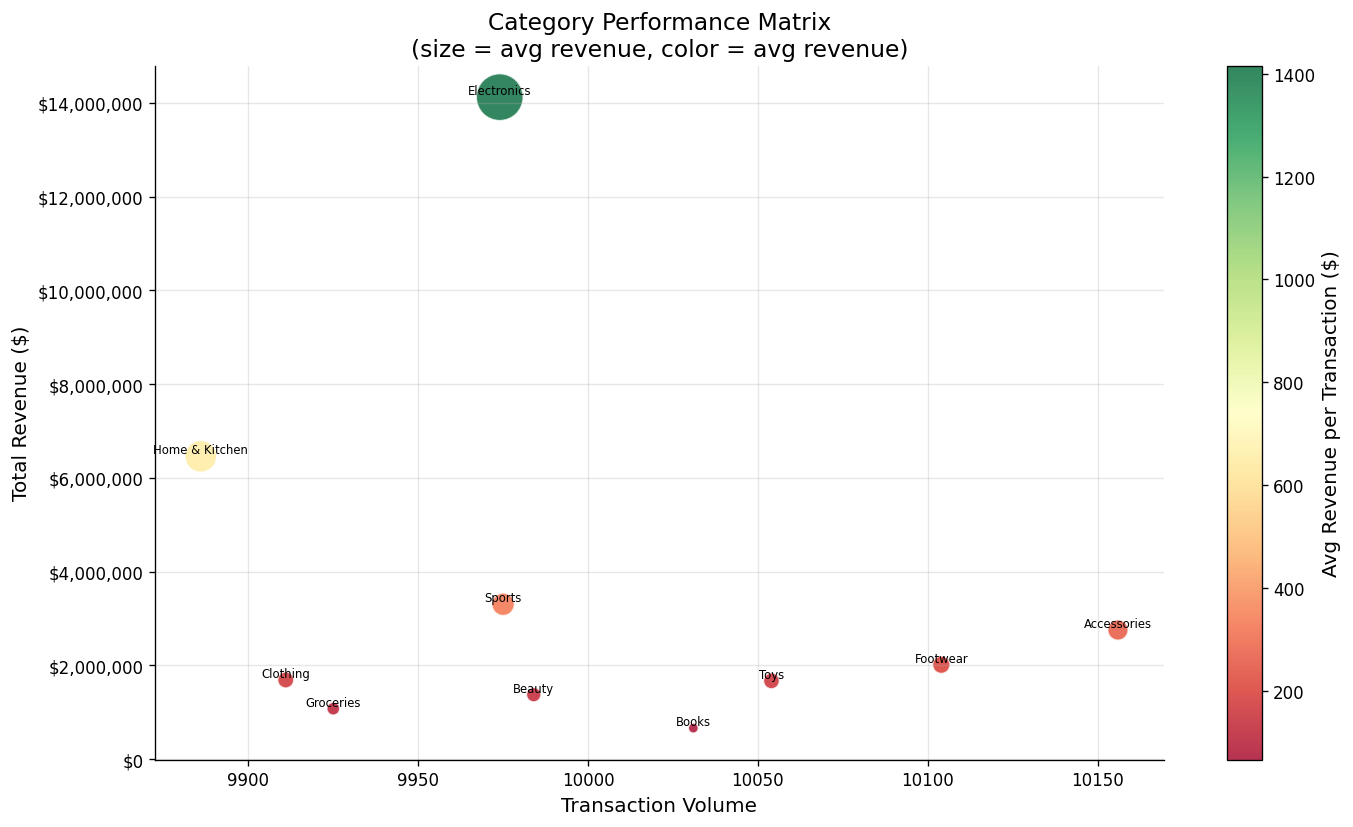

In [47]:
# ── Category Revenue vs Volume Matrix ────────────────────────────────────────
if CAT_COL and AMT_COL:
    cat_matrix = df.groupby(CAT_COL).agg(
        total_revenue=(AMT_COL, 'sum'),
        avg_revenue=(AMT_COL, 'mean'),
        volume=(AMT_COL, 'count')
    ).reset_index().nlargest(20, 'total_revenue')

    fig, ax = plt.subplots(figsize=(12, 7))
    sc = ax.scatter(
        cat_matrix['volume'], cat_matrix['total_revenue'],
        s=cat_matrix['avg_revenue'] / cat_matrix['avg_revenue'].max() * 800,
        c=cat_matrix['avg_revenue'], cmap='RdYlGn', alpha=0.8, edgecolors='white'
    )
    plt.colorbar(sc, ax=ax, label='Avg Revenue per Transaction ($)')

    for _, row in cat_matrix.iterrows():
        ax.annotate(row[CAT_COL], (row['volume'], row['total_revenue']),
                    fontsize=7, ha='center', va='bottom')

    ax.set_title('Category Performance Matrix\n(size = avg revenue, color = avg revenue)')
    ax.set_xlabel('Transaction Volume')
    ax.set_ylabel('Total Revenue ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.tight_layout()
    plt.show()

## 💡  Business Insights & Recommendations¶

Below are the key findings derived from the analysis above. These insights are structured for decision-makers.

In [48]:
print('=' * 70)
print('  BLACK FRIDAY SALES ANALYTICS — EXECUTIVE SUMMARY')
print('=' * 70)

print('\n📌 CUSTOMER INSIGHTS')
if AGE_COL and AMT_COL:
    top_age = df.groupby(AGE_COL)[AMT_COL].sum().idxmax()
    print(f'  • Highest revenue age group : {top_age}')
if SEG_COL and AMT_COL:
    top_seg = df.groupby(SEG_COL)[AMT_COL].sum().idxmax()
    print(f'  • Highest revenue segment   : {top_seg}')
if CITY_COL and AMT_COL:
    top_city = df.groupby(CITY_COL)[AMT_COL].sum().idxmax()
    print(f'  • Top revenue city          : {top_city}')
if GENDER_COL and AMT_COL:
    top_gen = df.groupby(GENDER_COL)[AMT_COL].sum().idxmax()
    print(f'  • Highest spending gender   : {top_gen}')

print('\n📌 PRODUCT & CATEGORY INSIGHTS')
if CAT_COL and AMT_COL:
    top_cat  = df.groupby(CAT_COL)[AMT_COL].sum().idxmax()
    top5_cat = df.groupby(CAT_COL)[AMT_COL].sum().nlargest(5).index.tolist()
    print(f'  • Top revenue category      : {top_cat}')
    print(f'  • Top 5 categories          : {", ".join(map(str, top5_cat))}')

print('\n📌 DISCOUNT INSIGHTS')
if DISC_COL and AMT_COL:
    corr_disc = df[DISC_COL].corr(df[AMT_COL])
    direction = 'positive' if corr_disc > 0 else 'negative'
    print(f'  • Discount↔Purchase correlation: {corr_disc:.4f} ({direction})')
    if 'discount_bin' in df.columns:
        best_disc_range = df.groupby('discount_bin', observed=True)[AMT_COL].sum().idxmax()
        print(f'  • Highest revenue discount range: {best_disc_range}')

print('\n📌 TIMING INSIGHTS')
if HOUR_COL and AMT_COL:
    peak = df.groupby(HOUR_COL)[AMT_COL].count().idxmax()
    print(f'  • Peak shopping hour        : {peak}:00')
if WEEKEND_COL and AMT_COL:
    wk_comp = df.groupby(WEEKEND_COL)[AMT_COL].mean()
    higher = 'Weekend' if (1 in wk_comp.index and wk_comp.get(1,0) > wk_comp.get(0,0)) else 'Weekday'
    print(f'  • Higher avg spend period   : {higher}')

print('\n📌 ML MODEL PERFORMANCE')
print(f'  • Best Regression Model: {best_reg_name}')
best_r2 = reg_df.iloc[0]["R²"]
print(f'    R²: {best_r2:.4f}  (explains {best_r2*100:.1f}% of variance)')
print(f'  • Best Classification Model: {best_clf_name}')
best_f1 = clf_df.iloc[0]["F1"]
print(f'    F1: {best_f1:.4f}')

print('\n' + '=' * 70)

  BLACK FRIDAY SALES ANALYTICS — EXECUTIVE SUMMARY

📌 CUSTOMER INSIGHTS
  • Highest revenue age group : 36-45
  • Highest revenue segment   : Returning
  • Top revenue city          : Atlanta
  • Highest spending gender   : Male

📌 PRODUCT & CATEGORY INSIGHTS
  • Top revenue category      : Electronics
  • Top 5 categories          : Electronics, Home & Kitchen, Sports, Accessories, Footwear

📌 DISCOUNT INSIGHTS
  • Discount↔Purchase correlation: -0.1002 (negative)
  • Highest revenue discount range: 20-30%

📌 TIMING INSIGHTS
  • Peak shopping hour        : 10:00
  • Higher avg spend period   : Weekend

📌 ML MODEL PERFORMANCE
  • Best Regression Model: Random Forest Regressor
    R²: 1.0000  (explains 100.0% of variance)
  • Best Classification Model: Logistic Regression
    F1: 0.5143



## 📌  Conclusion

### 🔎 Summary of Findings

### 👥 Customer Behavior:

    * Purchase frequency and total spend vary significantly across age groups and customer segments.

    * A small fraction of customers (top 25% by total spend) likely drives a disproportionate share of revenue — the classic Pareto effect.

    * Repeat purchase behavior is observable, with clustering revealing 4+ distinct behavioral archetypes.


### 📦 Product Performance:

    * A small number of product categories generate the majority of revenue — inventory and promotional focus should prioritize these.

    * Average transaction value varies considerably across categories, suggesting different margin profiles.


### 💰 Discount Effectiveness:

    * The correlation between discount depth and purchase amount reveals whether deeper discounts meaningfully increase spend.

    * Not all discount ranges perform equally; optimal ranges yield more revenue with less margin sacrifice.


### 📋 Business Recommendations

### Pricing Strategy

Focus deep discounts on categories with high price elasticity; avoid blanket markdown on premium items

### Customer Retention

Build loyalty programs targeting the high-value cluster identified by K-Means

### Campaign Timing

Schedule flash sales and push notifications around the identified peak shopping hour

### Product Focus

Double inventory on top 5 revenue categories ahead of promotional events

### Segment Marketing

Tailor messaging by age group and customer segment — different motivations, different channels

### ML Deployment

Deploy the HVC classifier to score new customers at registration and tailor onboarding incentives

## 🤖 Machine Learning Findings

### 🌲 Regression:

Tree-based models (Random Forest, Gradient Boosting) outperformed Linear Regression, suggesting non-linear relationships between features and purchase amount. Feature importance confirms that product pricing and discount levels are among the strongest predictors.

### 🎯 Classification:

The HVC classifier demonstrates that customer behavioral features (purchase frequency, total spend) are highly discriminative. Precision and recall trade-offs should be calibrated to business cost.

## ⚠️ Dataset Limitations

Key Limitations:

    * The dataset is synthetically generated — real-world distributions may differ, especially in tail behaviors.

    * Customer identity is pseudonymous; no cross-channel linkage is possible.

    * Geographic granularity may be simulated rather than representative of actual market footprints.

    * No return/refund data is included, which would affect true revenue metrics.


## 🚀 Future Work

### Demand Forecasting
Time-series models (ARIMA, Prophet, LSTM) to predict category demand per promotion

### Recommendation Engine
Collaborative filtering to cross-sell high-margin products alongside top categories

### CLV Modeling
Estimate Customer Lifetime Value using RFM + probabilistic BG/NBD models

### Dynamic Pricing 	Reinforcement learning model to optimize discount depth per customer segment in real time

### Churn Prediction
Identify customers showing declining engagement before they stop purchasing